In [1]:
!pip install torch --quiet

In [2]:
!pip install torchvision --quiet

# Setup and configuration

In [3]:
import os, json, random, time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.utils import resample

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [15]:
# Paths — MedNet isolated from v1
PREP_DIR        = Path("../images/MRI_preprocessed")
LABELS_CSV      = Path("../labels/MTA_labels.csv")
RESULTS_DIR_MedNet = Path("MTA_atrophy_MedicalNet/results_mta_atrophy")
RESULTS_DIR_MedNet.mkdir(parents=True, exist_ok=True)
SPLITS_FILE_MedNet = Path("MTA_atrophy_CNN/results_mta_atrophy/cv_splits_mta_atrophy.json")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [16]:
# Hyperparameters (defaults — will be overridden by search results for final run)
BATCH_SIZE   = 16
EPOCHS       = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 20
NUM_WORKERS  = 4

EXPERIMENT_NAME = "MTA_atrophy_MedNet"

# Load labels with confidence-based sample weights

In [17]:
labels_init = pd.read_csv(LABELS_CSV)

In [18]:
# Keep only images whose preprocessed file exists on disk
labels_init['has_file'] = labels_init['image_id'].apply(
    lambda i: (PREP_DIR / f"{i}.npy").exists())
labels = labels_init[labels_init['has_file']].drop(columns='has_file').reset_index(drop=True)

In [19]:
len(labels)

2020

In [20]:
# Verify everything is set up correctly
print(f"Total images:    {len(labels)}")
print(f"Total patients:  {labels['PTID'].nunique()}\n")

print(f"\nMTA_ATROPHY balance:")
print(labels_init['MTA_ATROPHY'].value_counts())
print(f"  positive: {100*labels['MTA_ATROPHY'].mean():.1f}%")

Total images:    2020
Total patients:  976


MTA_ATROPHY balance:
MTA_ATROPHY
0.0    1374
1.0     648
Name: count, dtype: int64
  positive: 32.1%


In [21]:
from sklearn.utils.class_weight import compute_sample_weight

n_neg, n_pos = (labels['MTA_ATROPHY'] == 0).sum(), (labels['MTA_ATROPHY'] == 1).sum()
beta = 0.5  # partial correction
labels['sample_weight'] = labels['MTA_ATROPHY'].apply(
    lambda y: (n_neg/n_pos)**beta if y == 1 else 1.0
)

# Verify
weighted_pos   = (labels['MTA_ATROPHY'] * labels['sample_weight']).sum()
weighted_total = labels['sample_weight'].sum()
print(f"Effective positive rate (weighted): {100*weighted_pos/weighted_total:.1f}%")
print(f"Unweighted positive rate:           {100*labels['MTA_ATROPHY'].mean():.1f}%")

Effective positive rate (weighted): 40.7%
Unweighted positive rate:           32.1%


# Patient-level 7-fold CV split

In [22]:
N_FOLDS = 7
VAL_FRACTION_OF_TRAIN = 0.125

In [23]:
from sklearn.model_selection import train_test_split

if SPLITS_FILE_MedNet.exists():
    with open(SPLITS_FILE_MedNet) as f:
        splits = json.load(f)
    print(f"✓ Loaded existing splits from {SPLITS_FILE_MedNet}")
else:
    print("Computing new patient-level CV splits...")

    patient_atrophy = (labels.groupby('PTID')['MTA_ATROPHY']
                    .agg(lambda x: x.mode().iloc[0])
                    .reset_index())
    patients = patient_atrophy['PTID'].values
    atrophy  = patient_atrophy['MTA_ATROPHY'].values
    print(f"  Total patients: {len(patients)}")

    # Hold out 15% of patients — never touched during CV
    cv_patients, holdout_patients, cv_atrophy, _ = train_test_split(
        patients, atrophy, test_size=0.1,
        stratify=atrophy, random_state=SEED)
    print(f"  CV patients: {len(cv_patients)}  |  Holdout patients: {len(holdout_patients)}")

    # Save holdout set to JSON
    holdout_df = labels[labels['PTID'].isin(holdout_patients)]
    holdout_record = {
        "holdout_patients": holdout_patients.tolist(),
        "image_ids":        holdout_df['image_id'].tolist(),
        "labels":           holdout_df['MTA_ATROPHY'].tolist(),
        "positive_rate":    float(holdout_df['MTA_ATROPHY'].mean()),
        "n_total":          int(len(holdout_df)),
        "n_patients":       int(len(holdout_patients)),
    }
    with open(RESULTS_DIR_MedNet / "holdout_inference_set.json", 'w') as f:
        json.dump(holdout_record, f, indent=2)
    print(f"  ✓ Holdout saved: {holdout_record['n_patients']} patients, "
          f"{holdout_record['n_total']} images, "
          f"{100*holdout_record['positive_rate']:.1f}% positive")

    # 7-fold CV on remaining 85%
    skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    splits = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(cv_patients, cv_atrophy)):
        test_patients     = cv_patients[test_idx].tolist()
        trainval_patients = cv_patients[trainval_idx]
        trainval_atrophy  = cv_atrophy[trainval_idx]

        val_skf = StratifiedKFold(n_splits=int(1 / VAL_FRACTION_OF_TRAIN),
                                   shuffle=True, random_state=SEED + fold_idx)
        train_idx_inner, val_idx_inner = next(val_skf.split(trainval_patients, trainval_atrophy))
        splits.append({
            "fold":           fold_idx,
            "train_patients": trainval_patients[train_idx_inner].tolist(),
            "val_patients":   trainval_patients[val_idx_inner].tolist(),
            "test_patients":  test_patients,
        })

    with open(SPLITS_FILE_MedNet, 'w') as f:
        json.dump(splits, f, indent=2)
    print(f"✓ Saved splits to {SPLITS_FILE_MedNet}")

✓ Loaded existing splits from MTA_atrophy_CNN/results_mta_atrophy/cv_splits_mta_atrophy.json


In [24]:
# No leakage check
for s in splits:
    assert not (set(s['train_patients']) & set(s['val_patients']))
    assert not (set(s['train_patients']) & set(s['test_patients']))
    assert not (set(s['val_patients'])   & set(s['test_patients']))
print("\n✓ No patient leakage")


✓ No patient leakage


In [25]:
print(f"\nMTA_ATROPHY positive rate per fold (test sets):")
for s in splits:
    te_df = labels[labels['PTID'].isin(s['test_patients'])]
    rate  = 100 * te_df['MTA_ATROPHY'].mean()
    print(f"  Fold {s['fold']}: {rate:.1f}%")


MTA_ATROPHY positive rate per fold (test sets):
  Fold 0: 34.7%
  Fold 1: 31.9%
  Fold 2: 30.9%
  Fold 3: 34.5%
  Fold 4: 28.4%
  Fold 5: 30.5%
  Fold 6: 32.7%


# Dataset (preloads to RAM, returns sample weight)

In [26]:
class ADNIDataset(Dataset):
    def __init__(self, df, prep_dir, target_col='MTA_ATROPHY', preload=True, training=False):
        self.image_ids      = df['image_id'].tolist()
        self.targets        = df[target_col].values.astype(np.float32)
        self.sample_weights = df['sample_weight'].values.astype(np.float32)
        self.prep_dir       = prep_dir
        self.training       = training
        self.preload        = preload

        if preload:
            self.cache = []
            for image_id in self.image_ids:
                arr = np.load(prep_dir / f"{image_id}.npy").astype(np.float32)
                self.cache.append(arr)
            print(f"  Preloaded {len(self.cache)} images "
                  f"({sum(a.nbytes for a in self.cache)/1e9:.1f} GB)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        arr = self.cache[idx] if self.preload else \
              np.load(self.prep_dir / f"{self.image_ids[idx]}.npy").astype(np.float32)
        x = torch.from_numpy(arr[None, ...]).float()
        y = torch.tensor(self.targets[idx],        dtype=torch.float32)
        w = torch.tensor(self.sample_weights[idx], dtype=torch.float32)
        return x, y, w

In [27]:
class FocalLoss(nn.Module):
    """
    Binary focal loss — Lin et al. 2017.
    Down-weights easy examples, up-weights hard ones (rare positives).

    alpha: balances positive vs negative class. 0.25 standard for imbalanced.
    gamma: focusing parameter. 2.0 standard.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets, sample_weights=None):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        focal   = (1 - p_t) ** self.gamma * bce
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss    = alpha_t * focal
        if sample_weights is not None:
            loss = loss * sample_weights
        return loss.mean()

# Helpers (evaluate, metrics, threshold tuning)

In [28]:
def evaluate(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, y, w in loader:
            x = x.to(device, non_blocking=True)
            with autocast():
                logits = model(x)
            all_logits.append(logits.float().cpu())
            all_labels.append(y)
    probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    labels = torch.cat(all_labels).numpy()
    return probs, labels


def find_best_threshold(probs, labels, n_thresholds=101, min_thr=0.3):
    thresholds = np.linspace(min_thr, 0.8, n_thresholds)
    best_score, best_thr = 0.0, 0.5
    for thr in thresholds:
        pred = (probs >= thr).astype(int)
        try:
            score = roc_auc_score(labels, pred)
        except ValueError:
            score = 0.0
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score


def threshold_tune_and_evaluate(probs, labels):
    n         = len(labels)
    skf       = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    all_preds = np.zeros_like(labels)
    used_thrs = []
    for tune_idx, eval_idx in skf.split(np.zeros(n), labels.astype(int)):
        thr, _ = find_best_threshold(probs[tune_idx], labels[tune_idx])
        used_thrs.append(thr)
        all_preds[eval_idx] = (probs[eval_idx] >= thr).astype(int)

    mean_threshold = float(np.mean(used_thrs))
    pred = all_preds

    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')

    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, pred, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()

    return {
        'threshold':   mean_threshold,
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((pred == labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(labels)),
        'n_positive': int(labels.sum()),
    }

# Visualization

In [29]:
import seaborn as sns
from sklearn.metrics import roc_curve

# ============================================================
# AGGREGATE RESULTS
# ============================================================
def aggregate_results_binary(all_results):
    summary = {}
    for metric in ['auc', 'precision', 'recall', 'f1', 'specificity', 'accuracy']:
        vals = [r['test_results'][metric] for r in all_results if r['test_results'] is not None]
        summary[metric] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals)), 'values': vals}
    for key in ['TP', 'FP', 'TN', 'FN']:
        vals = [r['test_results'][key] for r in all_results if r['test_results'] is not None]
        summary[key] = {'total': int(np.sum(vals)), 'values': vals}
    return summary


# ============================================================
# PRINT SUMMARY TABLE
# ============================================================
def print_summary_table(summary, experiment_name, all_results):
    print(f"\n{'='*65}")
    print(f"  FINAL RESULTS — {experiment_name}")
    print(f"  {len(all_results)} folds")
    print(f"{'='*65}")
    print(f"{'Metric':<15} | {'Mean':>10} | {'Std':>10} | {'Min':>8} | {'Max':>8}")
    print("-" * 60)
    for metric in ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']:
        m    = summary[metric]
        vals = m['values']
        print(f"  {metric:<13} | {m['mean']:>10.3f} | {m['std']:>10.3f} | "
              f"{min(vals):>8.3f} | {max(vals):>8.3f}")
    print(f"\n  Aggregated confusion matrix ({len(all_results)} folds combined):")
    print(f"  TP={summary['TP']['total']}  FP={summary['FP']['total']}  "
          f"TN={summary['TN']['total']}  FN={summary['FN']['total']}")
    print(f"\n  Per-fold breakdown:")
    print(f"  {'Fold':<6} {'AUC':>7} {'F1':>7} {'Prec':>7} {'Rec':>7} {'Spec':>7} {'Acc':>7} {'Thr':>7}")
    print(f"  {'-'*55}")
    for r in all_results:
        tr = r['test_results']
        print(f"  {r['fold']:<6} {tr['auc']:>7.3f} {tr['f1']:>7.3f} "
              f"{tr['precision']:>7.3f} {tr['recall']:>7.3f} "
              f"{tr['specificity']:>7.3f} {tr['accuracy']:>7.3f} "
              f"{tr['threshold']:>7.3f}")


# ============================================================
# PLOT 1: Training history
# ============================================================
def plot_training_history(all_results, exp_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for r in all_results:
        hist = pd.DataFrame(r['history'])
        axes[0].plot(hist['epoch'], hist['train_loss'], label=f"fold {r['fold']}")
        axes[1].plot(hist['epoch'], hist['val_auc'],   label=f"fold {r['fold']}")
    axes[0].set_title("Train Loss per Fold");    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].set_title("Validation AUC per Fold"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
    for ax in axes: ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "training_history.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 2: ROC curves
# ============================================================
def plot_roc_curves(all_results, exp_dir):
    fig, ax  = plt.subplots(figsize=(7, 7))
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)
    for r in all_results:
        probs    = np.array(r['test_probs'])
        lbls     = np.array(r['test_labels'])
        fpr, tpr, _ = roc_curve(lbls, probs)
        auc_val  = r['test_results']['auc']
        aucs.append(auc_val)
        ax.plot(fpr, tpr, alpha=0.3, color='steelblue',
                label=f"fold {r['fold']} (AUC={auc_val:.3f})")
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc  = np.std(aucs)
    ax.plot(mean_fpr, mean_tpr, color='red', lw=2,
            label=f"Mean ROC (AUC={mean_auc:.3f} \u00b1 {std_auc:.3f})")
    std_tpr = np.std(tprs, axis=0)
    ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    alpha=0.1, color='red', label='\u00b1 1 std')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title("ROC Curves — All Folds"); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "roc_curves.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 3: Confusion matrices
# ============================================================
def plot_confusion_matrices(all_results, exp_dir):
    n_folds  = len(all_results)
    ncols    = min(n_folds + 1, 4)
    nrows    = int(np.ceil((n_folds + 1) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes     = np.array(axes).flatten()
    cm_total = np.zeros((2, 2), dtype=int)
    for i, r in enumerate(all_results):
        probs     = np.array(r['test_probs'])
        lbls      = np.array(r['test_labels'])
        threshold = r['test_results'].get('threshold', 0.5)
        preds     = (probs >= threshold).astype(int)
        cm        = confusion_matrix(lbls, preds, labels=[0, 1])
        cm_total += cm
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        axes[i].set_title(f"Fold {r['fold']} (AUC={r['test_results']['auc']:.3f}, F1={r['test_results']['f1']:.3f})")
        axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[n_folds],
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    axes[n_folds].set_title(f"Combined ({n_folds} folds)")
    axes[n_folds].set_xlabel('Predicted'); axes[n_folds].set_ylabel('True')
    for j in range(n_folds + 1, len(axes)): axes[j].set_visible(False)
    plt.tight_layout()
    plt.savefig(exp_dir / "confusion_matrices.png", dpi=120)
    plt.show()


# ============================================================
# PLOT 4: Metrics boxplot
# ============================================================
def plot_metrics_boxplot(summary, exp_dir):
    metrics = ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']
    data    = [summary[m]['values'] for m in metrics]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.4),
               meanprops=dict(color='red', linewidth=2),
               medianprops=dict(color='navy', linewidth=2))
    for i, vals in enumerate(data):
        ax.scatter([i + 1] * len(vals), vals, alpha=0.6, color='red', zorder=3, s=40)
    ax.set_title("Metrics Across Folds (mean=red dashed, median=navy)")
    ax.set_ylabel("Score"); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(exp_dir / "metrics_boxplot.png", dpi=120)
    plt.show()


# ============================================================
# FULL REPORT
# ============================================================
def generate_experiment_report(all_results, summary, exp_dir, experiment_name):
    print_summary_table(summary, experiment_name, all_results)
    plot_training_history(all_results, exp_dir)
    plot_roc_curves(all_results, exp_dir)
    plot_confusion_matrices(all_results, exp_dir)
    plot_metrics_boxplot(summary, exp_dir)
    print(f"\n\u2713 All plots saved to: {exp_dir}")

# Architecture

In [31]:
WEIGHTS_DIR = Path("MTA_atrophy_MedNet/weights/medicalnet")
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_FILE = WEIGHTS_DIR / "resnet_10_23dataset.pth"

In [32]:
# ============================================================
# Try Hugging Face mirror for MedicalNet ResNet-10 weights
# ============================================================
try:
    from huggingface_hub import hf_hub_download
except ImportError:
    import os
    os.system("pip install huggingface_hub --quiet")
    from huggingface_hub import hf_hub_download

try:
    local_path = hf_hub_download(
        repo_id="TencentMedicalNet/MedicalNet-Resnet10",
        filename="resnet_10_23dataset.pth",
        local_dir=str(WEIGHTS_DIR),
    )
    print(f"✓ Downloaded to: {local_path}")
    print(f"  Size: {Path(local_path).stat().st_size / 1e6:.1f} MB")
except Exception as e:
    print(f"❌ HF download failed: {e}")
    print("→ Try Option 2 below")

✓ Downloaded to: MTA_atrophy_MedNet/weights/medicalnet/resnet_10_23dataset.pth
  Size: 57.5 MB


In [33]:
# ============================================================
# MedicalNet ResNet-10 architecture (matches the pretrained weights)
# + our classification head
# ============================================================
import torch
import torch.nn as nn

def conv3x3x3(in_planes, out_planes, stride=1):
    return nn.Conv3d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


class BasicBlock(nn.Module):
    """Standard 3D ResNet basic block."""
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = conv3x3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm3d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3x3(planes, planes)
        self.bn2 = nn.BatchNorm3d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class MedicalNetResNet10(nn.Module):
    """
    3D ResNet-10 matching MedicalNet's pretrained checkpoint
    + classification head (replaces segmentation conv_seg).
    
    Input:  (B, 1, D, H, W)  any size — but we use 96^3
    Output: (B,) binary logit
    """
    def __init__(self, n_classes=1, dropout=0.3):
        super().__init__()
        self.inplanes = 64

        # Stem (matches checkpoint: conv1 7x7x7, stride 2)
        self.conv1 = nn.Conv3d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm3d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)

        # Each layer has 1 block (ResNet-10 = [1,1,1,1])
        self.layer1 = self._make_layer(64,  blocks=1, stride=1)
        self.layer2 = self._make_layer(128, blocks=1, stride=2)
        self.layer3 = self._make_layer(256, blocks=1, stride=2)
        self.layer4 = self._make_layer(512, blocks=1, stride=2)

        # Our classification head (replaces conv_seg)
        self.avgpool = nn.AdaptiveAvgPool3d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, n_classes)

    def _make_layer(self, planes, blocks, stride):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv3d(self.inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm3d(planes),
            )
        layers = [BasicBlock(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)        # (B, 512)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)          # (B,)


def load_medicalnet_resnet10(weights_path, n_classes=1, dropout=0.3, freeze_backbone=False):
    """Build the model and load pretrained backbone weights."""
    model = MedicalNetResNet10(n_classes=n_classes, dropout=dropout)

    checkpoint = torch.load(weights_path, map_location="cpu", weights_only=False)
    pretrained = checkpoint['state_dict']

    # Strip "module." prefix from DataParallel checkpoint
    pretrained = {k.replace("module.", ""): v for k, v in pretrained.items()}

    # Load only matching keys (skips fc, since fc isn't in checkpoint)
    model_state = model.state_dict()
    matched = {k: v for k, v in pretrained.items()
               if k in model_state and v.shape == model_state[k].shape}
    skipped_pretrained = set(pretrained.keys()) - set(matched.keys())
    skipped_model      = set(model_state.keys()) - set(matched.keys())

    model_state.update(matched)
    model.load_state_dict(model_state)

    print(f"✓ Loaded {len(matched)}/{len(pretrained)} pretrained layers")
    if skipped_pretrained:
        print(f"  Skipped from checkpoint (not in our model): {list(skipped_pretrained)[:3]}")
    if skipped_model:
        print(f"  Random init in our model (not in checkpoint): {list(skipped_model)}")

    # Optionally freeze backbone for transfer learning
    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith('fc'):
                p.requires_grad = False
        print(f"  Froze backbone — only fc head will train")

    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params:     {n_total:,}")
    print(f"  Trainable params: {n_train:,}")

    return model


# ---------- Build model ----------
medicalnet_model = load_medicalnet_resnet10(
    weights_path=WEIGHTS_FILE,
    n_classes=1,
    dropout=0.3,
    freeze_backbone=False,    # full fine-tuning
)

# ---------- Smoke test forward pass ----------
medicalnet_model = medicalnet_model.to(DEVICE)
x_test = torch.randn(2, 1, 96, 96, 96).to(DEVICE)
medicalnet_model.eval()
with torch.no_grad():
    out = medicalnet_model(x_test)
print(f"\n✓ Forward pass works")
print(f"  Input:  {tuple(x_test.shape)}")
print(f"  Output: {tuple(out.shape)}  (expecting (2,))")

✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033

✓ Forward pass works
  Input:  (2, 1, 96, 96, 96)
  Output: (2,)  (expecting (2,))


# Training loop 

In [27]:
from sklearn.metrics import classification_report

def train_one_fold_medicalnet(fold_idx, splits, labels_df, prep_dir, device,
                               weights_path,
                               epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                               weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                               alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                               dropout=0.3, freeze_backbone=False,
                               exp_dir=None, verbose=True):

    fold     = splits[fold_idx]
    train_df = labels_df[labels_df['PTID'].isin(fold['train_patients'])].reset_index(drop=True)
    val_df   = labels_df[labels_df['PTID'].isin(fold['val_patients'])].reset_index(drop=True)
    test_df  = labels_df[labels_df['PTID'].isin(fold['test_patients'])].reset_index(drop=True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
        print(f"  MedicalNet ResNet-10 | freeze={freeze_backbone} | dropout={dropout}")
        print(f"  lr={lr:.0e}  wd={weight_decay:.0e}  Focal(α={alpha}, γ={gamma})")
        print(f"{'='*60}")

    train_ds = ADNIDataset(train_df, prep_dir, target_col=target_col, preload=True, training=True)
    val_ds   = ADNIDataset(val_df,   prep_dir, target_col=target_col, preload=True, training=False)
    test_ds  = ADNIDataset(test_df,  prep_dir, target_col=target_col, preload=True, training=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    model = load_medicalnet_resnet10(
        weights_path=weights_path, n_classes=1,
        dropout=dropout, freeze_backbone=freeze_backbone,
    ).to(device)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    scaler    = GradScaler()

    best_val_score, best_epoch, best_state = -1.0, -1, None
    epochs_no_improve = 0
    history = []

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, y, w in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            w = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')

        # macro F1 with threshold tuning — used for checkpoint selection
        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})

        if verbose:
            print(f"  ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score    = val_f1_macro
            best_epoch        = epoch
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  ⏹  Early stopping at epoch {epoch} (best: {best_epoch})")
                break

    # ---- Save weights ----
    if exp_dir is not None:
        torch.save(best_state, exp_dir / f"fold_{fold_idx}_best_model.pt")
        if verbose:
            print(f"  ✓ Weights saved → fold_{fold_idx}_best_model.pt")

    # ---- Test evaluation ----
    model.load_state_dict(best_state)
    val_probs, val_labels   = evaluate(model, val_loader, device)
    best_thr, _             = find_best_threshold(val_probs, val_labels)
    test_probs, test_labels = evaluate(model, test_loader, device)
    test_preds = (test_probs >= best_thr).astype(int)

    try:    auc = roc_auc_score(test_labels, test_probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

    test_results = {
        'threshold':   float(best_thr),
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((test_preds == test_labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(test_labels)),
        'n_positive': int(test_labels.sum()),
    }

    if verbose:
        print(f"\n  ✓ Best epoch: {best_epoch} | val macroF1: {best_val_score:.3f}")
        print(f"  ✓ Threshold: {best_thr:.3f} | AUC: {auc:.3f}")
        print(f"\n  TEST RESULTS:")
        print(classification_report(test_labels, test_preds,
              target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
        print(f"  Specificity: {test_results['specificity']:.3f}")
        print(f"  TP={tp} FP={fp} TN={tn} FN={fn}")

    del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model
    torch.cuda.empty_cache()

    return {
        'fold':          fold_idx,
        'best_epoch':    best_epoch,
        'best_val_auc':  best_val_score,   # stores macroF1 — consistent with CNN
        'test_results':  test_results,
        'test_probs':    test_probs.tolist(),
        'test_labels':   test_labels.tolist(),
        'history':       history,
        'config': {
            'alpha': alpha, 'gamma': gamma, 'lr': lr,
            'weight_decay': weight_decay, 'dropout': dropout,
            'freeze_backbone': freeze_backbone,
            'model': 'medicalnet_resnet10',
        },
    }

In [28]:
def run_all_folds_medicalnet(splits, labels_df, prep_dir, device, exp_dir,
                              weights_path,
                              alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                              dropout=0.3, freeze_backbone=False,
                              lr=LR, weight_decay=WEIGHT_DECAY,
                              epochs=EPOCHS, patience=PATIENCE):

    all_results = []
    total_t0    = time.time()

    for fold_idx in range(len(splits)):
        fold_file = exp_dir / f"fold_{fold_idx}.pkl"
        if fold_file.exists():
            print(f"\n[skip] Fold {fold_idx} already done — loading from disk")
            with open(fold_file, 'rb') as f:
                result = pickle.load(f)
            all_results.append(result)
            continue

        result = train_one_fold_medicalnet(
            fold_idx=fold_idx, splits=splits, labels_df=labels_df,
            prep_dir=prep_dir, device=device,
            weights_path=weights_path,
            epochs=epochs, patience=patience,
            lr=lr, weight_decay=weight_decay,
            alpha=alpha, gamma=gamma,
            dropout=dropout, freeze_backbone=freeze_backbone,
            target_col=target_col,
            exp_dir=exp_dir,
            verbose=True,
        )
        with open(fold_file, 'wb') as f:
            pickle.dump(result, f)
        all_results.append(result)

        elapsed = (time.time() - total_t0) / 60
        eta     = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1)
        aucs    = [r['test_results']['auc'] for r in all_results]
        f1s     = [r['test_results']['f1']  for r in all_results]
        print(f"\n📊 Cumulative ({fold_idx+1}/{len(splits)}) — elapsed {elapsed:.0f}m, ETA {eta:.0f}m")
        print(f"     AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        print(f"     F1  = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return all_results

# Hyperparameter Search — MedicalNet ResNet-10

## Strategy

We use **random search** (Bergstra & Bengio, 2012) over the joint space of optimisation
and transfer learning hyperparameters. Each candidate is evaluated on **fold 0 only**
with a reduced budget of **35 epochs** (early stopping patience = 10).

Checkpoint selection and config ranking both use **val macro F1** (with threshold tuning),
not AUC — ensuring the search directly optimises the precision/recall balance across
both classes rather than ranking quality alone.

The best configuration identified here is then used for the final 7-fold, 100-epoch run.

### Search space

| Parameter | Values | Note |
|---|---|---|
| learning rate | 1e-3, 3e-4, 1e-4, 5e-5 | log-scale |
| weight decay | 1e-3, 1e-4, 1e-5 | AdamW regularisation |
| dropout | 0.2, 0.3, 0.4, 0.5 | before classification head |
| focal α | 0.25, 0.35, 0.5 | class balance |
| focal γ | 1.5, 2.0, 3.0 | focusing strength |
| freeze backbone | True, False | head-only vs full fine-tuning |

> Architecture is fixed (ResNet-10) — no channel/depth search unlike the Small3DCNN.
> `freeze_backbone=True` trains only the linear head (~513 params);
> `freeze_backbone=False` fine-tunes all 14M parameters.

In [29]:
SEARCH_DIR_MEDNET          = RESULTS_DIR_MedNet / "hparam_search_mednet"
SEARCH_DIR_MEDNET.mkdir(exist_ok=True)
SEARCH_RESULTS_FILE_MEDNET = SEARCH_DIR_MEDNET / "search_results_mednet.json"

# Search space — no channel config (architecture is fixed ResNet-10)
# freeze_backbone is the key new axis vs CNN search
def random_config_mednet(seed):
    rng = random.Random(seed)
    return {
        "lr":              rng.choice([1e-3, 3e-4, 1e-4, 5e-5]),
        "weight_decay":    rng.choice([1e-3, 1e-4, 1e-5]),
        "dropout":         rng.choice([0.2, 0.3, 0.4, 0.5]),
        "focal_alpha":     rng.choice([0.25, 0.35, 0.5]),
        "focal_gamma":     rng.choice([1.5, 2.0, 3.0]),
        "freeze_backbone": rng.choice([True, False]),
    }

# Resume-safe
if SEARCH_RESULTS_FILE_MEDNET.exists():
    with open(SEARCH_RESULTS_FILE_MEDNET) as f:
        search_results_mednet = json.load(f)
    print(f"Resuming — {len(search_results_mednet)}/30 configs already done")
else:
    search_results_mednet = []

done_seeds_mednet = {r["seed"] for r in search_results_mednet}

for i in range(30):
    if i in done_seeds_mednet:
        print(f"[{i+1}/30] already done — skip")
        continue

    cfg = random_config_mednet(seed=i)
    print(f"\n[{i+1}/30] {cfg}")

    result = train_one_fold_medicalnet(
        fold_idx=0, splits=splits, labels_df=labels,
        prep_dir=PREP_DIR, device=DEVICE,
        weights_path=WEIGHTS_FILE,
        epochs=35, patience=10,
        lr=cfg["lr"], weight_decay=cfg["weight_decay"],
        alpha=cfg["focal_alpha"], gamma=cfg["focal_gamma"],
        dropout=cfg["dropout"], freeze_backbone=cfg["freeze_backbone"],
        target_col='MTA_ATROPHY',
        exp_dir=None, verbose=False,
    )

    val_f1_macro = result["best_val_auc"]   # stores macroF1
    print(f"  → val_macroF1 = {val_f1_macro:.3f}")

    search_results_mednet.append({
        "seed":          i,
        "config":        cfg,
        "val_macro_f1":  val_f1_macro,
    })

    with open(SEARCH_RESULTS_FILE_MEDNET, 'w') as f:
        json.dump(search_results_mednet, f, indent=2)

search_results_mednet.sort(key=lambda x: x["val_macro_f1"], reverse=True)
best_cfg_mednet = search_results_mednet[0]["config"]

print(f"\n✓ Search complete.")
print(f"  Best val_macroF1 = {search_results_mednet[0]['val_macro_f1']:.3f}")
print(f"  Best config = {best_cfg_mednet}")


[1/30] {'lr': 5e-05, 'weight_decay': 0.0001, 'dropout': 0.2, 'focal_alpha': 0.35, 'focal_gamma': 3.0, 'freeze_backbone': False}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033


/tmp/ipykernel_3408/3834742474.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is d

  → val_macroF1 = 0.875

[2/30] {'lr': 0.0003, 'weight_decay': 1e-05, 'dropout': 0.2, 'focal_alpha': 0.35, 'focal_gamma': 1.5, 'freeze_backbone': False}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033


/tmp/ipykernel_3408/3834742474.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is d

  → val_macroF1 = 0.872

[3/30] {'lr': 0.001, 'weight_decay': 0.001, 'dropout': 0.2, 'focal_alpha': 0.35, 'focal_gamma': 1.5, 'freeze_backbone': False}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033


...

  → val_macroF1 = 0.767

[29/30] {'lr': 0.001, 'weight_decay': 1e-05, 'dropout': 0.3, 'focal_alpha': 0.5, 'focal_gamma': 3.0, 'freeze_backbone': True}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Froze backbone — only fc head will train
  Total params:     14,356,033
  Trainable params: 513


/tmp/ipykernel_3408/3834742474.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is d

  → val_macroF1 = 0.796

[30/30] {'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.4, 'focal_alpha': 0.25, 'focal_gamma': 3.0, 'freeze_backbone': False}
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033


/tmp/ipykernel_3408/3834742474.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is d

  → val_macroF1 = 0.888

✓ Search complete.
  Best val_macroF1 = 0.904
  Best config = {'lr': 0.001, 'weight_decay': 1e-05, 'dropout': 0.3, 'focal_alpha': 0.35, 'focal_gamma': 3.0, 'freeze_backbone': False}


In [30]:
print(f"\n{'='*95}")
print(f"  MEDICALNET SEARCH — Top 10 / {len(search_results_mednet)} configs  "
      f"(fold 0 proxy, 35 epochs, sorted by macro F1)")
print(f"{'='*95}")
print(f"  {'#':<4} {'macroF1':>8}  {'freeze':<7} {'lr':>8} {'wd':>8} "
      f"{'dropout':>8} {'alpha':>6} {'gamma':>6}")
print(f"  {'-'*75}")
for rank, r in enumerate(search_results_mednet[:10]):
    c = r["config"]
    print(f"  {rank+1:<4} {r['val_macro_f1']:>8.3f}  {str(c['freeze_backbone']):<7} "
          f"{c['lr']:>8.0e} {c['weight_decay']:>8.0e} "
          f"{c['dropout']:>8.2f} {c['focal_alpha']:>6.2f} {c['focal_gamma']:>6.1f}")


  MEDICALNET SEARCH — Top 10 / 30 configs  (fold 0 proxy, 35 epochs, sorted by macro F1)
  #     macroF1  freeze        lr       wd  dropout  alpha  gamma
  ---------------------------------------------------------------------------
  1       0.904  False      1e-03    1e-05     0.30   0.35    3.0
  2       0.895  False      3e-04    1e-04     0.50   0.50    2.0
  3       0.890  False      3e-04    1e-04     0.20   0.50    2.0
  4       0.888  False      1e-03    1e-04     0.40   0.25    3.0
  5       0.882  False      1e-03    1e-05     0.20   0.50    1.5
  6       0.877  False      1e-04    1e-03     0.20   0.50    2.0
  7       0.875  False      5e-05    1e-04     0.20   0.35    3.0
  8       0.873  False      3e-04    1e-05     0.30   0.35    3.0
  9       0.872  False      3e-04    1e-05     0.20   0.35    1.5
  10      0.865  False      1e-03    1e-03     0.20   0.35    1.5


# Final run — best config, all 7 folds, 100 epochs

Selected configuration:
  lr                   = 0.001
  weight_decay         = 1e-05
  dropout              = 0.3
  focal_alpha          = 0.35
  focal_gamma          = 3.0
  freeze_backbone      = False

Fold 0 | Train 1314 | Val 206 | Test 297
  MedicalNet ResNet-10 | freeze=False | dropout=0.3
  lr=1e-03  wd=1e-05  Focal(α=0.35, γ=3.0)
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Total params:     14,356,033
  Trainable params: 14,356,033


/tmp/ipykernel_3408/3834742474.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  0  loss=0.0436  val_AUC=0.867  val_macroF1=0.818  [9s]


/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep  1  loss=0.0391  val_AUC=0.852  val_macroF1=0.797  [8s]


...

  ep 41  loss=0.0002  val_AUC=0.842  val_macroF1=0.785  [9s]


/tmp/ipykernel_3408/3834742474.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep 42  loss=0.0002  val_AUC=0.835  val_macroF1=0.778  [8s]
  ⏹  Early stopping at epoch 42 (best: 22)
  ✓ Weights saved → fold_6_best_model.pt


/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best epoch: 22 | val macroF1: 0.815
  ✓ Threshold: 0.645 | AUC: 0.820

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.831     0.791     0.811       187
Atrophic (1)      0.610     0.670     0.639        91

    accuracy                          0.752       278
   macro avg      0.721     0.731     0.725       278
weighted avg      0.759     0.752     0.755       278

  Specificity: 0.791
  TP=61 FP=39 TN=148 FN=30

📊 Cumulative (7/7) — elapsed 37m, ETA 0m
     AUC = 0.862 ± 0.021
     F1  = 0.675 ± 0.059

✓ ALL FOLDS COMPLETE — MedicalNet ResNet-10

  FINAL RESULTS — medicalnet_resnet10
  7 folds
Metric          |       Mean |        Std |      Min |      Max
------------------------------------------------------------
  auc           |      0.862 |      0.021 |    0.820 |    0.890
  f1            |      0.675 |      0.059 |    0.566 |    0.754
  precision     |      0.737 |      0.065 |    0.610 |    0.842
  recall        |      0.640 |

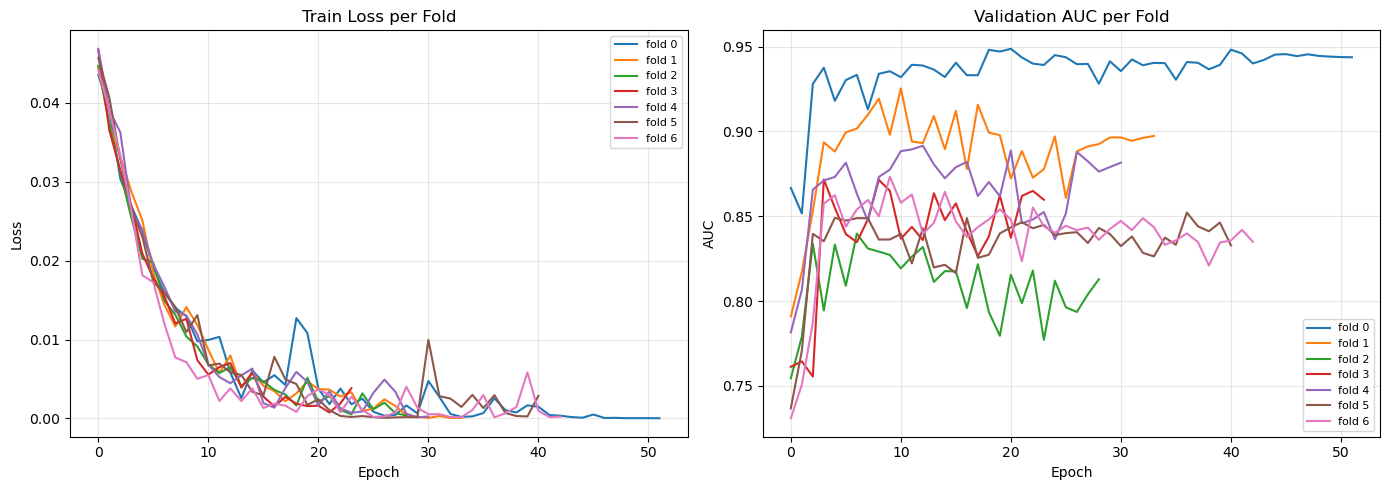

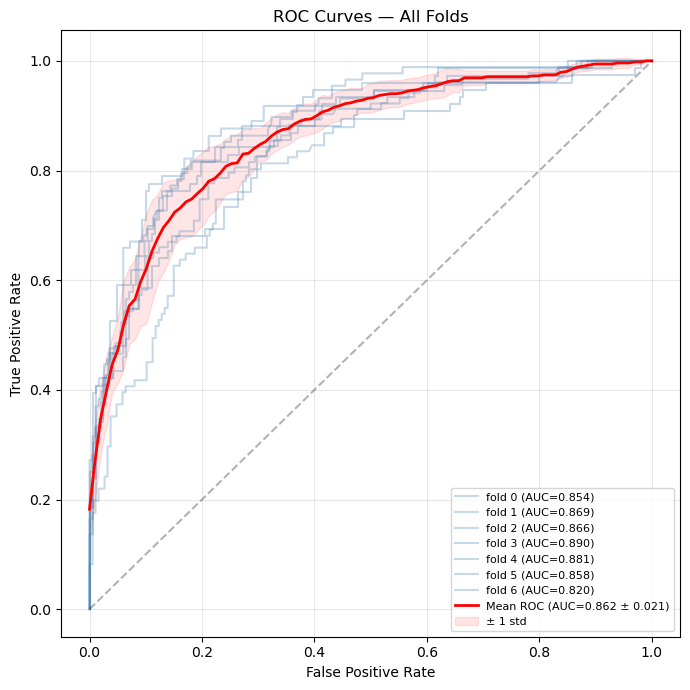

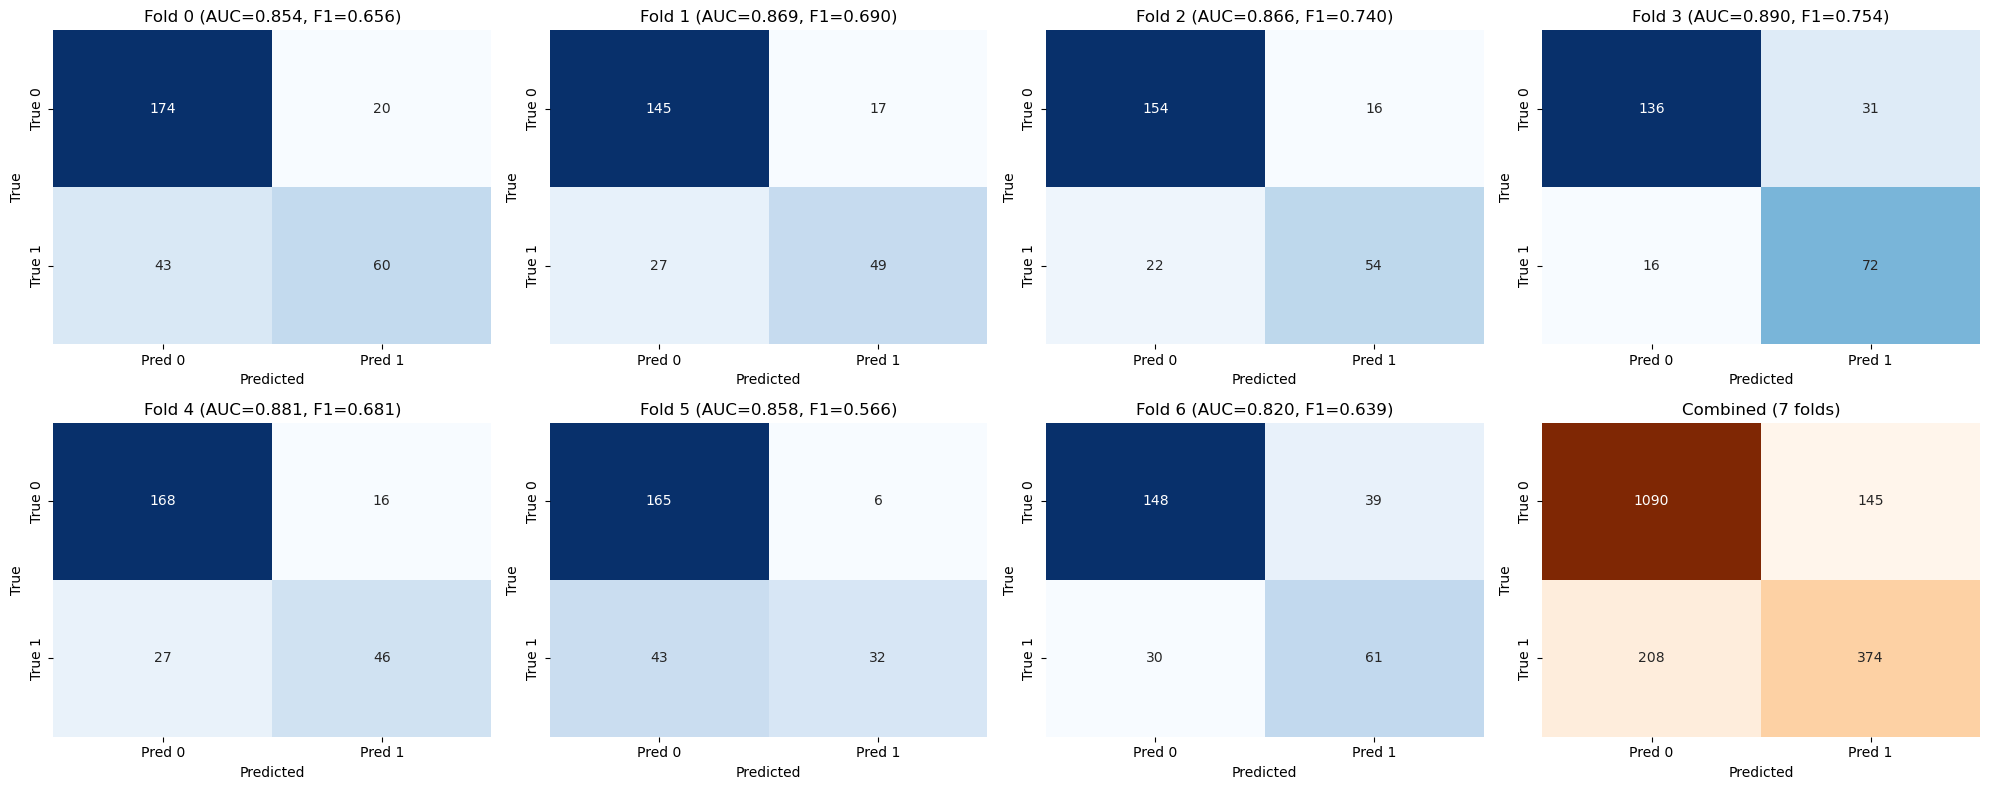

/tmp/ipykernel_3408/3365572909.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,


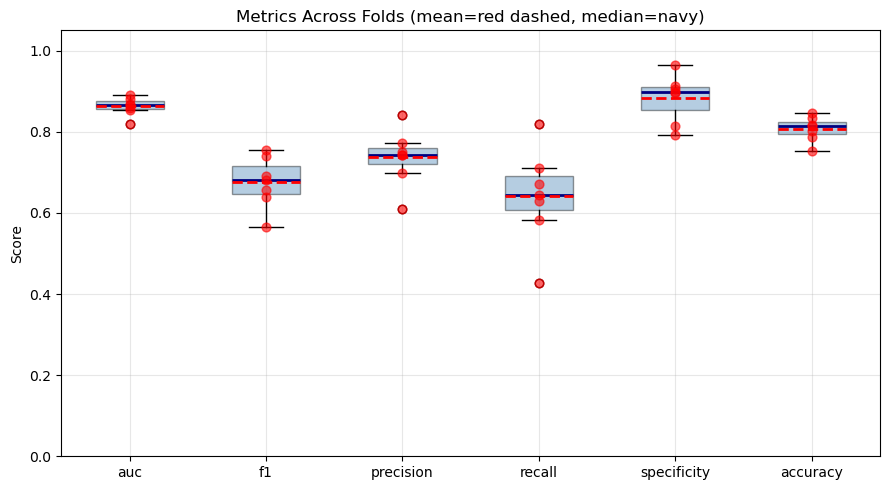


✓ All plots saved to: MTA_atrophy_MedicalNet/results_mta_atrophy/final_mednet_macroF1


In [31]:
import shutil

best_cfg_mednet = search_results_mednet[0]["config"]
print("Selected configuration:")
for k, v in best_cfg_mednet.items():
    print(f"  {k:<20} = {v}")

FINAL_DIR_MEDNET = RESULTS_DIR_MedNet / "final_mednet_macroF1"
shutil.rmtree(FINAL_DIR_MEDNET, ignore_errors=True)
FINAL_DIR_MEDNET.mkdir(exist_ok=True)

all_results_mednet = run_all_folds_medicalnet(
    splits=splits, labels_df=labels,
    prep_dir=PREP_DIR, device=DEVICE,
    exp_dir=FINAL_DIR_MEDNET,
    weights_path=WEIGHTS_FILE,
    lr=best_cfg_mednet["lr"],
    weight_decay=best_cfg_mednet["weight_decay"],
    alpha=best_cfg_mednet["focal_alpha"],
    gamma=best_cfg_mednet["focal_gamma"],
    dropout=best_cfg_mednet["dropout"],
    freeze_backbone=best_cfg_mednet["freeze_backbone"],
    target_col='MTA_ATROPHY',
    epochs=EPOCHS,
    patience=PATIENCE,
)

print(f"\n{'='*55}")
print(f"✓ ALL FOLDS COMPLETE — MedicalNet ResNet-10")
print(f"{'='*55}")

summary_mednet = aggregate_results_binary(all_results_mednet)
generate_experiment_report(all_results_mednet, summary_mednet, FINAL_DIR_MEDNET, "medicalnet_resnet10")

# MedicalNet - 2 stages

In [32]:
from sklearn.metrics import classification_report

def train_one_fold_medicalnet_2stage(fold_idx, splits, labels_df, prep_dir, device,
                                      weights_path,
                                      epochs_stage1=10, epochs_stage2=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      lr_stage1=1e-3, lr_stage2=1e-4,
                                      weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                                      alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                                      dropout=0.3,
                                      exp_dir=None, verbose=True):

    fold     = splits[fold_idx]
    train_df = labels_df[labels_df['PTID'].isin(fold['train_patients'])].reset_index(drop=True)
    val_df   = labels_df[labels_df['PTID'].isin(fold['val_patients'])].reset_index(drop=True)
    test_df  = labels_df[labels_df['PTID'].isin(fold['test_patients'])].reset_index(drop=True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
        print(f"  MedicalNet ResNet-10 — 2-stage | dropout={dropout}")
        print(f"  Stage 1: head only    LR={lr_stage1:.0e}  {epochs_stage1} epochs")
        print(f"  Stage 2: full finetune LR={lr_stage2:.0e}  up to {epochs_stage2} epochs")
        print(f"  Focal(α={alpha}, γ={gamma})  wd={weight_decay:.0e}")
        print(f"{'='*60}")

    train_ds = ADNIDataset(train_df, prep_dir, target_col=target_col, preload=True, training=True)
    val_ds   = ADNIDataset(val_df,   prep_dir, target_col=target_col, preload=True, training=False)
    test_ds  = ADNIDataset(test_df,  prep_dir, target_col=target_col, preload=True, training=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    model = load_medicalnet_resnet10(
        weights_path=weights_path, n_classes=1,
        dropout=dropout, freeze_backbone=True,
    ).to(device)

    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    scaler    = GradScaler()

    best_val_score, best_epoch, best_stage, best_state = -1.0, -1, -1, None
    history = []

    # ============================================================
    # STAGE 1 — head only
    # ============================================================
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr_stage1, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_stage1)

    if verbose:
        print(f"\n--- STAGE 1: head only ---")

    for epoch in range(epochs_stage1):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, y, w in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            w = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')

        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'stage': 1, 'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})
        if verbose:
            print(f"  S1 ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score = val_f1_macro
            best_epoch     = epoch
            best_stage     = 1
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ============================================================
    # STAGE 2 — unfreeze backbone, fine-tune everything
    # ============================================================
    for p in model.parameters():
        p.requires_grad = True
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"\n--- STAGE 2: full fine-tune ({n_train:,} trainable params) ---")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_stage2, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_stage2)

    epochs_no_improve = 0
    for epoch in range(epochs_stage2):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, y, w in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            w = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')

        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'stage': 2, 'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})
        if verbose:
            print(f"  S2 ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score    = val_f1_macro
            best_epoch        = epoch
            best_stage        = 2
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  ⏹  Early stopping at S2 epoch {epoch} "
                          f"(best: stage {best_stage} ep {best_epoch})")
                break

    # ---- Save weights ----
    if exp_dir is not None:
        torch.save(best_state, exp_dir / f"fold_{fold_idx}_best_model.pt")
        if verbose:
            print(f"  ✓ Weights saved → fold_{fold_idx}_best_model.pt")

    # ---- Test evaluation ----
    model.load_state_dict(best_state)
    val_probs, val_labels   = evaluate(model, val_loader, device)
    best_thr, _             = find_best_threshold(val_probs, val_labels)
    test_probs, test_labels = evaluate(model, test_loader, device)
    test_preds = (test_probs >= best_thr).astype(int)

    try:    auc = roc_auc_score(test_labels, test_probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

    test_results = {
        'threshold':   float(best_thr),
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((test_preds == test_labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(test_labels)),
        'n_positive': int(test_labels.sum()),
    }

    if verbose:
        print(f"\n  ✓ Best: stage {best_stage} epoch {best_epoch} | val macroF1: {best_val_score:.3f}")
        print(f"  ✓ Threshold: {best_thr:.3f} | AUC: {auc:.3f}")
        print(f"\n  TEST RESULTS:")
        print(classification_report(test_labels, test_preds,
              target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
        print(f"  Specificity: {test_results['specificity']:.3f}")
        print(f"  TP={tp} FP={fp} TN={tn} FN={fn}")

    del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model
    torch.cuda.empty_cache()

    return {
        'fold':          fold_idx,
        'best_epoch':    best_epoch,
        'best_stage':    best_stage,
        'best_val_auc':  best_val_score,   # stores macroF1
        'test_results':  test_results,
        'test_probs':    test_probs.tolist(),
        'test_labels':   test_labels.tolist(),
        'history':       history,
        'config': {
            'alpha': alpha, 'gamma': gamma,
            'lr_stage1': lr_stage1, 'lr_stage2': lr_stage2,
            'weight_decay': weight_decay, 'dropout': dropout,
            'epochs_stage1': epochs_stage1,
            'model': 'medicalnet_resnet10_2stage',
        },
    }

In [33]:
def run_all_folds_medicalnet_2stage(splits, labels_df, prep_dir, device, exp_dir,
                                     weights_path,
                                     alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                                     dropout=0.3,
                                     epochs_stage1=10, epochs_stage2=EPOCHS,
                                     lr_stage1=1e-3, lr_stage2=1e-4,
                                     weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    all_results = []
    total_t0    = time.time()

    for fold_idx in range(len(splits)):
        fold_file = exp_dir / f"fold_{fold_idx}.pkl"
        if fold_file.exists():
            print(f"\n[skip] Fold {fold_idx} already done — loading from disk")
            with open(fold_file, 'rb') as f:
                result = pickle.load(f)
            all_results.append(result)
            continue

        result = train_one_fold_medicalnet_2stage(
            fold_idx=fold_idx, splits=splits, labels_df=labels_df,
            prep_dir=prep_dir, device=device,
            weights_path=weights_path,
            epochs_stage1=epochs_stage1, epochs_stage2=epochs_stage2,
            lr_stage1=lr_stage1, lr_stage2=lr_stage2,
            weight_decay=weight_decay, patience=patience,
            alpha=alpha, gamma=gamma,
            dropout=dropout, target_col=target_col,
            exp_dir=exp_dir, verbose=True,
        )
        with open(fold_file, 'wb') as f:
            pickle.dump(result, f)
        all_results.append(result)

        elapsed = (time.time() - total_t0) / 60
        eta     = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1)
        aucs    = [r['test_results']['auc'] for r in all_results]
        f1s     = [r['test_results']['f1']  for r in all_results]
        print(f"\n📊 Cumulative ({fold_idx+1}/{len(splits)}) — elapsed {elapsed:.0f}m, ETA {eta:.0f}m")
        print(f"     AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        print(f"     F1  = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

    return all_results

2-stage config (inherited from single-stage search):
  lr_stage1     = 1e-3   (standard head warmup)
  lr_stage2     = 1e-03  (from search)
  weight_decay  = 1e-05  (from search)
  dropout       = 0.3   (from search)
  focal_alpha   = 0.35  (from search)
  focal_gamma   = 3.0  (from search)

Fold 0 | Train 1314 | Val 206 | Test 297
  MedicalNet ResNet-10 — 2-stage | dropout=0.3
  Stage 1: head only    LR=1e-03  10 epochs
  Stage 2: full finetune LR=1e-03  up to 100 epochs
  Focal(α=0.35, γ=3.0)  wd=1e-05
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init in our model (not in checkpoint): ['fc.weight', 'fc.bias']
  Froze backbone — only fc head will train
  Total params:     14,356,033
  Trainable params: 513

--- STAGE 1: head only ---


/tmp/ipykernel_3408/222501566.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_3408/222501566.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S1 ep  0  loss=0.0490  val_AUC=0.833  val_macroF1=0.784  [5s]


/tmp/ipykernel_3408/222501566.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S1 ep  1  loss=0.0466  val_AUC=0.820  val_macroF1=0.771  [4s]


...

  S2 ep 41  loss=0.0000  val_AUC=0.888  val_macroF1=0.791  [8s]


/tmp/ipykernel_3408/222501566.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S2 ep 42  loss=0.0001  val_AUC=0.889  val_macroF1=0.801  [8s]
  ⏹  Early stopping at S2 epoch 42 (best: stage 2 ep 22)
  ✓ Weights saved → fold_6_best_model.pt


/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3408/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best: stage 2 epoch 22 | val macroF1: 0.823
  ✓ Threshold: 0.305 | AUC: 0.836

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.857     0.802     0.829       187
Atrophic (1)      0.641     0.725     0.680        91

    accuracy                          0.777       278
   macro avg      0.749     0.764     0.755       278
weighted avg      0.786     0.777     0.780       278

  Specificity: 0.802
  TP=66 FP=37 TN=150 FN=25

📊 Cumulative (7/7) — elapsed 40m, ETA 0m
     AUC = 0.877 ± 0.033
     F1  = 0.715 ± 0.035

✓ ALL FOLDS COMPLETE — medicalnet_resnet10_2stage

  FINAL RESULTS — medicalnet_resnet10_2stage
  7 folds
Metric          |       Mean |        Std |      Min |      Max
------------------------------------------------------------
  auc           |      0.877 |      0.033 |    0.836 |    0.940
  f1            |      0.715 |      0.035 |    0.673 |    0.782
  precision     |      0.739 |      0.075 |    0.641 |    0.867
  recall 

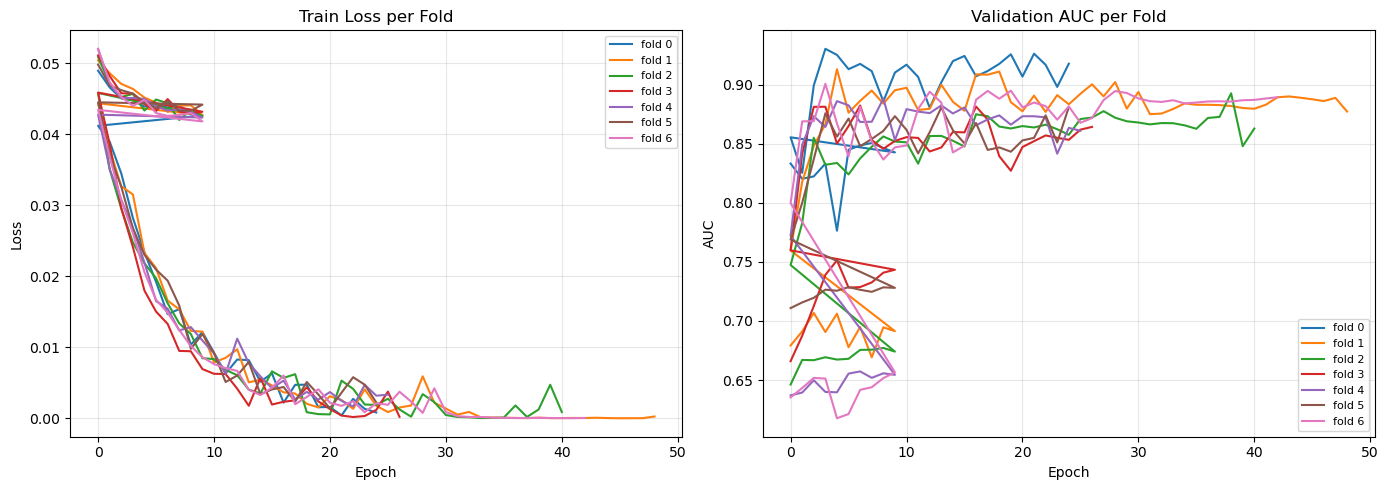

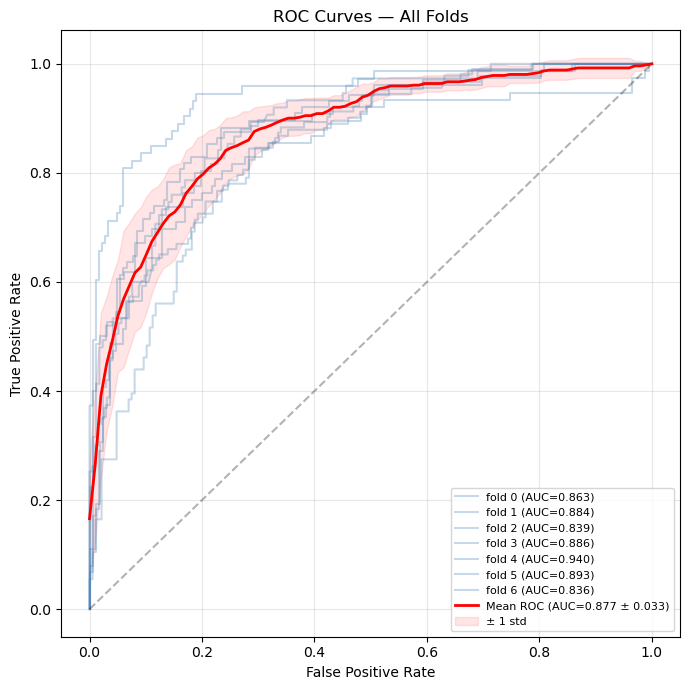

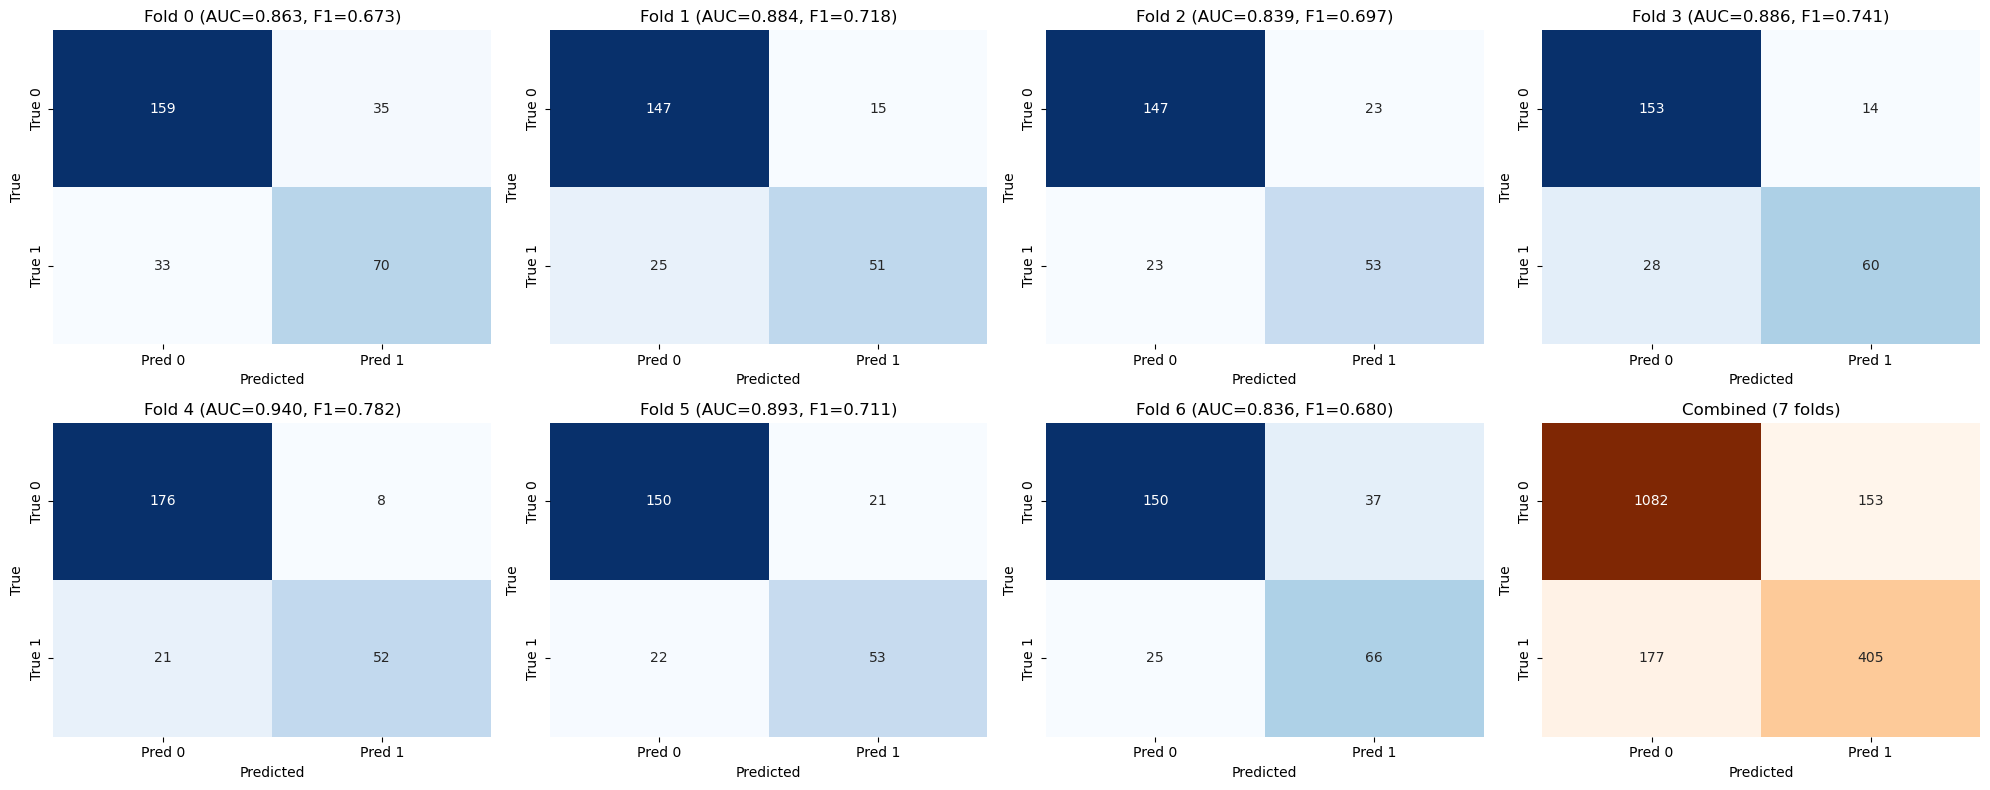

/tmp/ipykernel_3408/3365572909.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,


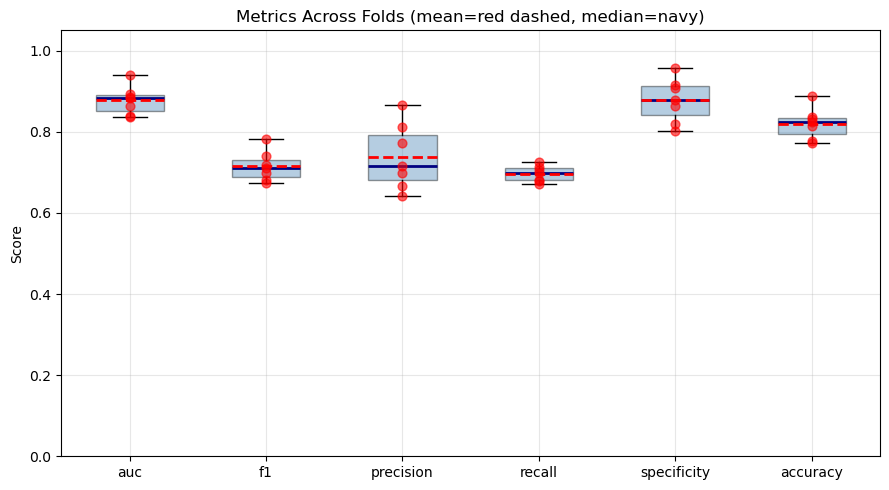


✓ All plots saved to: MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_2stage


In [34]:
import shutil

# Reuse best_cfg_mednet from single-stage search — same data, same loss, same head
# Only lr_stage1 is new: 1e-3 is standard for head warmup
print("2-stage config (inherited from single-stage search):")
print(f"  lr_stage1     = 1e-3   (standard head warmup)")
print(f"  lr_stage2     = {best_cfg_mednet['lr']:.0e}  (from search)")
print(f"  weight_decay  = {best_cfg_mednet['weight_decay']:.0e}  (from search)")
print(f"  dropout       = {best_cfg_mednet['dropout']}   (from search)")
print(f"  focal_alpha   = {best_cfg_mednet['focal_alpha']}  (from search)")
print(f"  focal_gamma   = {best_cfg_mednet['focal_gamma']}  (from search)")

EXPERIMENT_NAME_2STAGE = "medicalnet_resnet10_2stage"
EXP_DIR_2STAGE = RESULTS_DIR_MedNet / EXPERIMENT_NAME_2STAGE
shutil.rmtree(EXP_DIR_2STAGE, ignore_errors=True)
EXP_DIR_2STAGE.mkdir(exist_ok=True)

all_results_mednet_2stage = run_all_folds_medicalnet_2stage(
    splits=splits, labels_df=labels,
    prep_dir=PREP_DIR, device=DEVICE,
    exp_dir=EXP_DIR_2STAGE,
    weights_path=WEIGHTS_FILE,
    lr_stage1=1e-3,
    lr_stage2=best_cfg_mednet["lr"],
    weight_decay=best_cfg_mednet["weight_decay"],
    alpha=best_cfg_mednet["focal_alpha"],
    gamma=best_cfg_mednet["focal_gamma"],
    dropout=best_cfg_mednet["dropout"],
    target_col='MTA_ATROPHY',
    epochs_stage1=10,
    epochs_stage2=EPOCHS,
    patience=PATIENCE,
)

print(f"\n{'='*55}")
print(f"✓ ALL FOLDS COMPLETE — {EXPERIMENT_NAME_2STAGE}")
print(f"{'='*55}")

summary_mednet_2stage = aggregate_results_binary(all_results_mednet_2stage)
generate_experiment_report(
    all_results_mednet_2stage, summary_mednet_2stage,
    EXP_DIR_2STAGE, EXPERIMENT_NAME_2STAGE)

# MedNet -- Demographic fusion

In [34]:
# WEIGHTS_FILE already defined above — reuse it
assert WEIGHTS_FILE.exists(), f"Not found: {WEIGHTS_FILE}"
print(f"✓ MedicalNet weights ready: {WEIGHTS_FILE} ({WEIGHTS_FILE.stat().st_size/1e6:.1f} MB)")

EXPERIMENT_NAME_DEMO = "medicalnet_resnet10_demo"
EXP_DIR_DEMO         = RESULTS_DIR_MedNet / EXPERIMENT_NAME_DEMO   # ← was RESULTS_DIR_V2
EXP_DIR_DEMO.mkdir(parents=True, exist_ok=True)

✓ MedicalNet weights ready: MTA_atrophy_MedNet/weights/medicalnet/resnet_10_23dataset.pth (57.5 MB)


In [35]:
DEMO_COLS = ['PTGENDER', 'AGE', 'PTEDUCAT']
for c in DEMO_COLS:
    assert c in labels.columns, f"Missing column: {c}. Available: {list(labels.columns)}"

n_missing   = labels[DEMO_COLS].isna().any(axis=1).sum()
labels_demo = labels.dropna(subset=DEMO_COLS).reset_index(drop=True)

print(f"Dropped {n_missing} rows with missing demographics")
print(f"Using {len(labels_demo)} / {len(labels)} rows for demo-fusion experiment")
print(f"\nGender:    {labels_demo['PTGENDER'].value_counts().to_dict()}")
print(f"Age:       {labels_demo['AGE'].mean():.1f} ± {labels_demo['AGE'].std():.1f}  "
      f"[{labels_demo['AGE'].min():.0f}–{labels_demo['AGE'].max():.0f}]")
print(f"Education: {labels_demo['PTEDUCAT'].mean():.1f} ± {labels_demo['PTEDUCAT'].std():.1f}  "
      f"[{labels_demo['PTEDUCAT'].min():.0f}–{labels_demo['PTEDUCAT'].max():.0f}]")

Dropped 0 rows with missing demographics
Using 2020 / 2020 rows for demo-fusion experiment

Gender:    {1.0: 1014, 2.0: 1006}
Age:       74.4 ± 7.8  [51–104]
Education: 16.4 ± 2.5  [8–20]


In [36]:
def fit_demo_scaler(train_df):
    """Fit normalisation stats on TRAIN fold only — prevents leakage."""
    return {
        'age_mean': float(train_df['AGE'].mean()),
        'age_std':  float(train_df['AGE'].std() + 1e-8),
        'edu_mean': float(train_df['PTEDUCAT'].mean()),
        'edu_std':  float(train_df['PTEDUCAT'].std() + 1e-8),
    }

def transform_demo(df, scaler):
    """Convert df → (N, 3) float32 array of [gender, age_z, edu_z]."""
    gender = (df['PTGENDER'].astype(str).str.upper().str[0] == 'F').astype(np.float32).values
    age    = ((df['AGE'].values      - scaler['age_mean']) / scaler['age_std']).astype(np.float32)
    edu    = ((df['PTEDUCAT'].values - scaler['edu_mean']) / scaler['edu_std']).astype(np.float32)
    return np.stack([gender, age, edu], axis=1)

In [37]:
class ADNIDatasetDemo(Dataset):
    """
    Wraps ADNIDataset and additionally returns a demographic feature vector.
    Returns: (image, demo, target, weight)
       image  : (1, D, H, W) float tensor
       demo   : (3,) float tensor  — [gender, age_z, edu_z]
       target : scalar float
       weight : scalar float
    """
    def __init__(self, df, prep_dir, demo_array,
                 target_col='MTA_ATROPHY', preload=True, training=False):
        assert len(df) == len(demo_array), "demo_array length must match df"
        self.base = ADNIDataset(df, prep_dir, target_col=target_col,
                                preload=preload, training=training)
        self.demo = torch.from_numpy(demo_array).float()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y, w = self.base[idx]
        return x, self.demo[idx], y, w

In [38]:
def evaluate_demo(model, loader, device):
    """Same as evaluate() but unpacks (x, demo, y, w) loaders."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, demo, y, w in loader:
            x    = x.to(device, non_blocking=True)
            demo = demo.to(device, non_blocking=True)
            with autocast():
                logits = model(x, demo)
            all_logits.append(logits.float().cpu())
            all_labels.append(y)
    probs  = torch.sigmoid(torch.cat(all_logits)).numpy()
    labels = torch.cat(all_labels).numpy()
    return probs, labels

In [39]:
class MedicalNetResNet10Demo(nn.Module):
    def __init__(self, n_demo_features=3, demo_hidden=16,
                 n_classes=1, dropout=0.3):
        super().__init__()
        self.inplanes = 64

        # Backbone — layer names identical to MedicalNetResNet10 → weights load cleanly
        self.conv1   = nn.Conv3d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm3d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self._make_layer(64,  blocks=1, stride=1)
        self.layer2  = self._make_layer(128, blocks=1, stride=2)
        self.layer3  = self._make_layer(256, blocks=1, stride=2)
        self.layer4  = self._make_layer(512, blocks=1, stride=2)
        self.avgpool = nn.AdaptiveAvgPool3d(1)

        # Demographic encoder (small MLP, random init)
        self.demo_encoder = nn.Sequential(
            nn.Linear(n_demo_features, demo_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(demo_hidden, demo_hidden),
            nn.ReLU(inplace=True),
        )

        # Fused classification head (random init)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512 + demo_hidden, n_classes)

    def _make_layer(self, planes, blocks, stride):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                nn.Conv3d(self.inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm3d(planes),
            )
        layers = [BasicBlock(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x, demo):
        h = self.relu(self.bn1(self.conv1(x)))
        h = self.maxpool(h)
        h = self.layer1(h); h = self.layer2(h)
        h = self.layer3(h); h = self.layer4(h)
        h = self.avgpool(h).flatten(1)       # (B, 512)
        d = self.demo_encoder(demo)          # (B, demo_hidden)
        z = torch.cat([h, d], dim=1)
        z = self.dropout(z)
        return self.fc(z).squeeze(1)         # (B,)


def load_medicalnet_resnet10_demo(weights_path, n_demo_features=3, demo_hidden=16,
                                   n_classes=1, dropout=0.3,
                                   freeze_backbone=False, verbose=True):
    """Build the fusion model and load pretrained backbone (head + demo encoder random init)."""
    model = MedicalNetResNet10Demo(
        n_demo_features=n_demo_features, demo_hidden=demo_hidden,
        n_classes=n_classes, dropout=dropout)

    checkpoint = torch.load(weights_path, map_location="cpu", weights_only=False)
    pretrained = checkpoint['state_dict']
    pretrained = {k.replace("module.", ""): v for k, v in pretrained.items()}

    model_state   = model.state_dict()
    matched       = {k: v for k, v in pretrained.items()
                     if k in model_state and v.shape == model_state[k].shape}
    skipped_model = set(model_state.keys()) - set(matched.keys())

    model_state.update(matched)
    model.load_state_dict(model_state)

    if verbose:
        print(f"✓ Loaded {len(matched)}/{len(pretrained)} pretrained layers")
        if skipped_model:
            print(f"  Random init: {len(skipped_model)} layers (demo_encoder + fc)")

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not (name.startswith('fc') or name.startswith('demo_encoder')):
                p.requires_grad = False
        if verbose:
            print(f"  Froze backbone — demo_encoder + fc head will train")

    if verbose:
        n_total = sum(p.numel() for p in model.parameters())
        n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Total params:     {n_total:,}")
        print(f"  Trainable params: {n_train:,}")

    return model

In [40]:
from sklearn.metrics import classification_report

def train_one_fold_medicalnet_demo_2stage(fold_idx, splits, labels_df, prep_dir, device,
                                          weights_path,
                                          epochs_stage1=10, epochs_stage2=EPOCHS,
                                          batch_size=BATCH_SIZE,
                                          lr_stage1=1e-3, lr_stage2=1e-4,
                                          weight_decay=WEIGHT_DECAY, patience=PATIENCE,
                                          alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                                          dropout=0.3, demo_hidden=16,
                                          exp_dir=None, verbose=True):

    fold     = splits[fold_idx]
    train_df = labels_df[labels_df['PTID'].isin(fold['train_patients'])].reset_index(drop=True)
    val_df   = labels_df[labels_df['PTID'].isin(fold['val_patients'])].reset_index(drop=True)
    test_df  = labels_df[labels_df['PTID'].isin(fold['test_patients'])].reset_index(drop=True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx} | Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}")
        print(f"  MedicalNet ResNet-10 + Demographics — 2-stage | demo_hidden={demo_hidden}  dropout={dropout}")
        print(f"  Stage 1: head+demo only  LR={lr_stage1:.0e}  {epochs_stage1} epochs")
        print(f"  Stage 2: full finetune   LR={lr_stage2:.0e}  up to {epochs_stage2} epochs")
        print(f"  Focal(α={alpha}, γ={gamma})  wd={weight_decay:.0e}")
        print(f"{'='*60}")

    # Fit demographic scaler on TRAIN fold only — no leakage
    demo_scaler = fit_demo_scaler(train_df)
    train_demo  = transform_demo(train_df, demo_scaler)
    val_demo    = transform_demo(val_df,   demo_scaler)
    test_demo   = transform_demo(test_df,  demo_scaler)

    if verbose:
        print(f"  Demo scaler: age μ={demo_scaler['age_mean']:.1f} σ={demo_scaler['age_std']:.1f} | "
              f"edu μ={demo_scaler['edu_mean']:.1f} σ={demo_scaler['edu_std']:.1f}")

    train_ds = ADNIDatasetDemo(train_df, prep_dir, train_demo,
                               target_col=target_col, preload=True, training=True)
    val_ds   = ADNIDatasetDemo(val_df,   prep_dir, val_demo,
                               target_col=target_col, preload=True, training=False)
    test_ds  = ADNIDatasetDemo(test_df,  prep_dir, test_demo,
                               target_col=target_col, preload=True, training=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

    # Start with backbone frozen → only demo_encoder + fc train in stage 1
    model = load_medicalnet_resnet10_demo(
        weights_path=weights_path, n_demo_features=3,
        demo_hidden=demo_hidden, n_classes=1,
        dropout=dropout, freeze_backbone=True, verbose=verbose,
    ).to(device)

    criterion = FocalLoss(alpha=alpha, gamma=gamma)
    scaler    = GradScaler()

    best_val_score, best_epoch, best_stage, best_state = -1.0, -1, -1, None
    history = []

    # ============================================================
    # STAGE 1 — head + demo encoder only (backbone frozen)
    # ============================================================
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr_stage1, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_stage1)

    if verbose:
        print(f"\n--- STAGE 1: head + demo encoder only ---")

    for epoch in range(epochs_stage1):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, demo, y, w in train_loader:
            x    = x.to(device, non_blocking=True)
            demo = demo.to(device, non_blocking=True)
            y    = y.to(device, non_blocking=True)
            w    = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x, demo)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate_demo(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')
        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'stage': 1, 'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})
        if verbose:
            print(f"  S1 ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score = val_f1_macro
            best_epoch     = epoch
            best_stage     = 1
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ============================================================
    # STAGE 2 — unfreeze backbone, fine-tune everything
    # ============================================================
    for p in model.parameters():
        p.requires_grad = True
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if verbose:
        print(f"\n--- STAGE 2: full fine-tune ({n_train:,} trainable params) ---")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_stage2, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_stage2)

    epochs_no_improve = 0
    for epoch in range(epochs_stage2):
        t0 = time.time()
        model.train()
        train_loss_sum, train_n = 0.0, 0

        for x, demo, y, w in train_loader:
            x    = x.to(device, non_blocking=True)
            demo = demo.to(device, non_blocking=True)
            y    = y.to(device, non_blocking=True)
            w    = w.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast():
                logits = model(x, demo)
                loss   = criterion(logits, y, sample_weights=w)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss_sum += loss.item() * x.size(0)
            train_n        += x.size(0)

        scheduler.step()
        train_loss = train_loss_sum / train_n

        val_probs, val_labels = evaluate_demo(model, val_loader, device)
        try:    val_auc = roc_auc_score(val_labels, val_probs)
        except: val_auc = float('nan')
        best_thr_val, _       = find_best_threshold(val_probs, val_labels)
        val_preds             = (val_probs >= best_thr_val).astype(int)
        _, _, val_f1_macro, _ = precision_recall_fscore_support(
            val_labels, val_preds, average='macro', zero_division=0)

        epoch_time = time.time() - t0
        history.append({'stage': 2, 'epoch': epoch, 'train_loss': train_loss,
                        'val_auc': val_auc, 'val_f1_macro': val_f1_macro,
                        'time_sec': epoch_time})
        if verbose:
            print(f"  S2 ep {epoch:2d}  loss={train_loss:.4f}  "
                  f"val_AUC={val_auc:.3f}  val_macroF1={val_f1_macro:.3f}  [{epoch_time:.0f}s]")

        if val_f1_macro > best_val_score:
            best_val_score    = val_f1_macro
            best_epoch        = epoch
            best_stage        = 2
            best_state        = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  ⏹  Early stopping at S2 epoch {epoch} "
                          f"(best: stage {best_stage} ep {best_epoch})")
                break

    # ---- Save weights ----
    if exp_dir is not None:
        torch.save(best_state, exp_dir / f"fold_{fold_idx}_best_model.pt")
        if verbose:
            print(f"  ✓ Weights saved → fold_{fold_idx}_best_model.pt")

    # ---- Test evaluation ----
    model.load_state_dict(best_state)
    val_probs, val_labels   = evaluate_demo(model, val_loader, device)
    best_thr, _             = find_best_threshold(val_probs, val_labels)
    test_probs, test_labels = evaluate_demo(model, test_loader, device)
    test_preds = (test_probs >= best_thr).astype(int)

    try:    auc = roc_auc_score(test_labels, test_probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

    test_results = {
        'threshold':   float(best_thr),
        'auc':         float(auc),
        'f1':          float(f1),
        'precision':   float(prec),
        'recall':      float(rec),
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else float('nan'),
        'accuracy':    float((test_preds == test_labels).mean()),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'n_total':    int(len(test_labels)),
        'n_positive': int(test_labels.sum()),
    }

    if verbose:
        print(f"\n  ✓ Best: stage {best_stage} epoch {best_epoch} | val macroF1: {best_val_score:.3f}")
        print(f"  ✓ Threshold: {best_thr:.3f} | AUC: {auc:.3f}")
        print(f"\n  TEST RESULTS:")
        print(classification_report(test_labels, test_preds,
              target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
        print(f"  Specificity: {test_results['specificity']:.3f}")
        print(f"  TP={tp} FP={fp} TN={tn} FN={fn}")

    del train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, model
    torch.cuda.empty_cache()

    return {
        'fold':          fold_idx,
        'best_epoch':    best_epoch,
        'best_stage':    best_stage,
        'best_val_auc':  best_val_score,   # stores macroF1
        'test_results':  test_results,
        'test_probs':    test_probs.tolist(),
        'test_labels':   test_labels.tolist(),
        'history':       history,
        'demo_scaler':   demo_scaler,
        'config': {
            'alpha': alpha, 'gamma': gamma,
            'lr_stage1': lr_stage1, 'lr_stage2': lr_stage2,
            'weight_decay': weight_decay, 'dropout': dropout,
            'demo_hidden': demo_hidden, 'epochs_stage1': epochs_stage1,
            'model': 'medicalnet_resnet10_demo_2stage',
        },
    }

In [41]:
def run_all_folds_medicalnet_demo_2stage(splits, labels_df, prep_dir, device, exp_dir,
                                         weights_path,
                                         alpha=0.5, gamma=2.0, target_col='MTA_ATROPHY',
                                         dropout=0.3, demo_hidden=16,
                                         epochs_stage1=10, epochs_stage2=EPOCHS,
                                         lr_stage1=1e-3, lr_stage2=1e-4,
                                         weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    all_results = []
    total_t0    = time.time()
    for fold_idx in range(len(splits)):
        fold_file = exp_dir / f"fold_{fold_idx}.pkl"
        if fold_file.exists():
            print(f"\n[skip] Fold {fold_idx} already done — loading from disk")
            with open(fold_file, 'rb') as f:
                all_results.append(pickle.load(f))
            continue
        result = train_one_fold_medicalnet_demo_2stage(
            fold_idx=fold_idx, splits=splits, labels_df=labels_df,
            prep_dir=prep_dir, device=device,
            weights_path=weights_path,
            epochs_stage1=epochs_stage1, epochs_stage2=epochs_stage2,
            lr_stage1=lr_stage1, lr_stage2=lr_stage2,
            weight_decay=weight_decay, patience=patience,
            alpha=alpha, gamma=gamma,
            dropout=dropout, demo_hidden=demo_hidden,
            target_col=target_col,
            exp_dir=exp_dir, verbose=True,
        )
        with open(fold_file, 'wb') as f:
            pickle.dump(result, f)
        all_results.append(result)
        elapsed = (time.time() - total_t0) / 60
        eta     = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1)
        aucs    = [r['test_results']['auc'] for r in all_results]
        f1s     = [r['test_results']['f1']  for r in all_results]
        print(f"\n📊 Cumulative ({fold_idx+1}/{len(splits)}) — elapsed {elapsed:.0f}m, ETA {eta:.0f}m")
        print(f"     AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        print(f"     F1  = {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    return all_results

In [43]:
best_cfg_mednet = {
    "lr":              1e-3,
    "weight_decay":    1e-5,
    "dropout":         0.3,
    "focal_alpha":     0.35,
    "focal_gamma":     3.0,
    "freeze_backbone": False,
}
print("Sweeping demo_hidden on fold 0 (2-stage) — reusing best_cfg_mednet for all else\n")
demo_hidden_results = []
for dh in [16, 32, 64]:
    print(f"\n  demo_hidden = {dh}")
    result = train_one_fold_medicalnet_demo_2stage(
        fold_idx=0, splits=splits, labels_df=labels_demo,
        prep_dir=PREP_DIR, device=DEVICE,
        weights_path=WEIGHTS_FILE,
        epochs_stage1=10, epochs_stage2=35, patience=10,
        lr_stage1=1e-3,
        lr_stage2=best_cfg_mednet["lr"],
        weight_decay=best_cfg_mednet["weight_decay"],
        alpha=best_cfg_mednet["focal_alpha"],
        gamma=best_cfg_mednet["focal_gamma"],
        dropout=best_cfg_mednet["dropout"],
        demo_hidden=dh,
        target_col='MTA_ATROPHY',
        exp_dir=None, verbose=False,
    )
    f1 = result["best_val_auc"]
    print(f"  → val_macroF1 = {f1:.3f}")
    demo_hidden_results.append({"demo_hidden": dh, "val_macro_f1": f1})
demo_hidden_results.sort(key=lambda x: x["val_macro_f1"], reverse=True)
best_demo_hidden = demo_hidden_results[0]["demo_hidden"]
print(f"\n  demo_hidden sweep results:")
for r in demo_hidden_results:
    print(f"    demo_hidden={r['demo_hidden']}  →  val_macroF1={r['val_macro_f1']:.3f}")
print(f"\n  ✓ Selected demo_hidden = {best_demo_hidden}")

Sweeping demo_hidden on fold 0 (2-stage) — reusing best_cfg_mednet for all else


  demo_hidden = 16
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_8617/3169764090.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is

  → val_macroF1 = 0.887

  demo_hidden = 32
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_8617/3169764090.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is

  → val_macroF1 = 0.892

  demo_hidden = 64
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)


/tmp/ipykernel_8617/3169764090.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is

  → val_macroF1 = 0.879

  demo_hidden sweep results:
    demo_hidden=32  →  val_macroF1=0.892
    demo_hidden=16  →  val_macroF1=0.887
    demo_hidden=64  →  val_macroF1=0.879

  ✓ Selected demo_hidden = 32


In [44]:
import shutil
EXPERIMENT_NAME_DEMO = "medicalnet_resnet10_demo_2stage"   # new name → keeps single-stage demo intact
EXP_DIR_DEMO = RESULTS_DIR_MedNet / EXPERIMENT_NAME_DEMO
shutil.rmtree(EXP_DIR_DEMO, ignore_errors=True)
EXP_DIR_DEMO.mkdir(exist_ok=True)

print("Final configuration (2-stage demo fusion):")
print(f"  lr_stage1     = 1e-3   (standard head warmup)")
print(f"  lr_stage2     = {best_cfg_mednet['lr']:.0e}  (from MedNet search)")
print(f"  weight_decay  = {best_cfg_mednet['weight_decay']:.0e}  (from MedNet search)")
print(f"  dropout       = {best_cfg_mednet['dropout']}   (from MedNet search)")
print(f"  focal_alpha   = {best_cfg_mednet['focal_alpha']}  (from MedNet search)")
print(f"  focal_gamma   = {best_cfg_mednet['focal_gamma']}  (from MedNet search)")
print(f"  demo_hidden   = {best_demo_hidden}   (from sweep)")

all_results_mednet_demo = run_all_folds_medicalnet_demo_2stage(
    splits=splits, labels_df=labels_demo,
    prep_dir=PREP_DIR, device=DEVICE,
    exp_dir=EXP_DIR_DEMO,
    weights_path=WEIGHTS_FILE,
    lr_stage1=1e-3,
    lr_stage2=best_cfg_mednet["lr"],
    weight_decay=best_cfg_mednet["weight_decay"],
    alpha=best_cfg_mednet["focal_alpha"],
    gamma=best_cfg_mednet["focal_gamma"],
    dropout=best_cfg_mednet["dropout"],
    demo_hidden=best_demo_hidden,
    epochs_stage1=10,
    epochs_stage2=EPOCHS,
    patience=PATIENCE,
)

print(f"\n{'='*55}")
print(f"✓ ALL FOLDS COMPLETE — {EXPERIMENT_NAME_DEMO}")
print(f"{'='*55}")

Final configuration (2-stage demo fusion):
  lr_stage1     = 1e-3   (standard head warmup)
  lr_stage2     = 1e-03  (from MedNet search)
  weight_decay  = 1e-05  (from MedNet search)
  dropout       = 0.3   (from MedNet search)
  focal_alpha   = 0.35  (from MedNet search)
  focal_gamma   = 3.0  (from MedNet search)
  demo_hidden   = 32   (from sweep)

Fold 0 | Train 1314 | Val 206 | Test 297
  MedicalNet ResNet-10 + Demographics — 2-stage | demo_hidden=32  dropout=0.3
  Stage 1: head+demo only  LR=1e-03  10 epochs
  Stage 2: full finetune   LR=1e-03  up to 100 epochs
  Focal(α=0.35, γ=3.0)  wd=1e-05
  Demo scaler: age μ=74.2 σ=7.7 | edu μ=16.4 σ=2.6
  Preloaded 1314 images (4.7 GB)
  Preloaded 206 images (0.7 GB)
  Preloaded 297 images (1.1 GB)
✓ Loaded 72/72 pretrained layers
  Random init: 6 layers (demo_encoder + fc)
  Froze backbone — demo_encoder + fc head will train
  Total params:     14,357,249
  Trainable params: 1,729

--- STAGE 1: head + demo encoder only ---


/tmp/ipykernel_8617/3169764090.py:59: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()
/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S1 ep  0  loss=0.0492  val_AUC=0.801  val_macroF1=0.755  [4s]


/tmp/ipykernel_8617/3169764090.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S1 ep  1  loss=0.0451  val_AUC=0.799  val_macroF1=0.745  [4s]


...

  S2 ep 23  loss=0.0037  val_AUC=0.840  val_macroF1=0.757  [8s]


/tmp/ipykernel_8617/3169764090.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  S2 ep 24  loss=0.0035  val_AUC=0.802  val_macroF1=0.714  [8s]
  ⏹  Early stopping at S2 epoch 24 (best: stage 2 ep 4)
  ✓ Weights saved → fold_6_best_model.pt


/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  ✓ Best: stage 2 epoch 4 | val macroF1: 0.806
  ✓ Threshold: 0.410 | AUC: 0.860

  TEST RESULTS:
              precision    recall  f1-score   support

 Healthy (0)      0.822     0.840     0.831       187
Atrophic (1)      0.655     0.626     0.640        91

    accuracy                          0.770       278
   macro avg      0.739     0.733     0.736       278
weighted avg      0.767     0.770     0.768       278

  Specificity: 0.840
  TP=57 FP=30 TN=157 FN=34

📊 Cumulative (7/7) — elapsed 38m, ETA 0m
     AUC = 0.876 ± 0.035
     F1  = 0.724 ± 0.060

✓ ALL FOLDS COMPLETE — medicalnet_resnet10_demo_2stage



  FINAL RESULTS — medicalnet_resnet10_demo_2stage
  7 folds
Metric          |       Mean |        Std |      Min |      Max
------------------------------------------------------------
  auc           |      0.876 |      0.035 |    0.820 |    0.917
  f1            |      0.724 |      0.060 |    0.640 |    0.822
  precision     |      0.737 |      0.059 |    0.655 |    0.824
  recall        |      0.713 |      0.068 |    0.626 |    0.841
  specificity   |      0.881 |      0.029 |    0.840 |    0.930
  accuracy      |      0.827 |      0.039 |    0.770 |    0.875

  Aggregated confusion matrix (7 folds combined):
  TP=413  FP=148  TN=1087  FN=169

  Per-fold breakdown:
  Fold       AUC      F1    Prec     Rec    Spec     Acc     Thr
  -------------------------------------------------------
  0        0.842   0.684   0.733   0.641   0.876   0.795   0.635
  1        0.820   0.671   0.671   0.671   0.846   0.790   0.320
  2        0.872   0.743   0.764   0.724   0.900   0.846   0.300
  3 

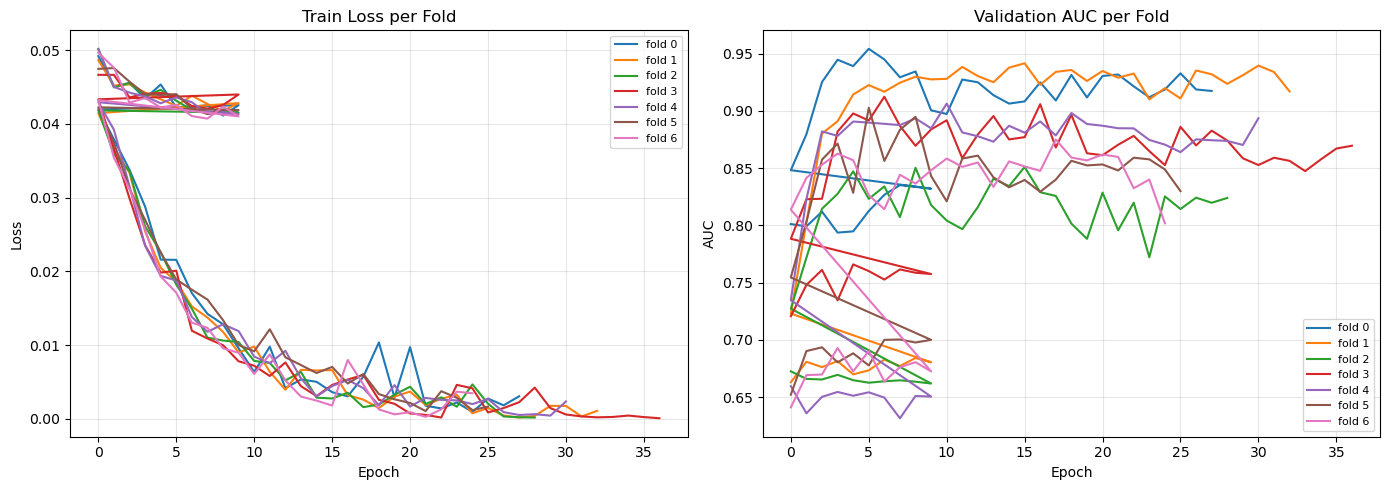

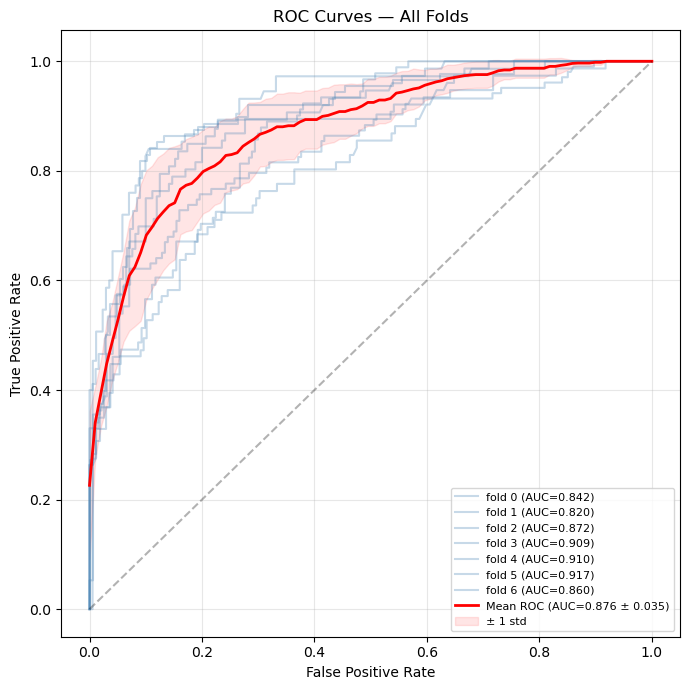

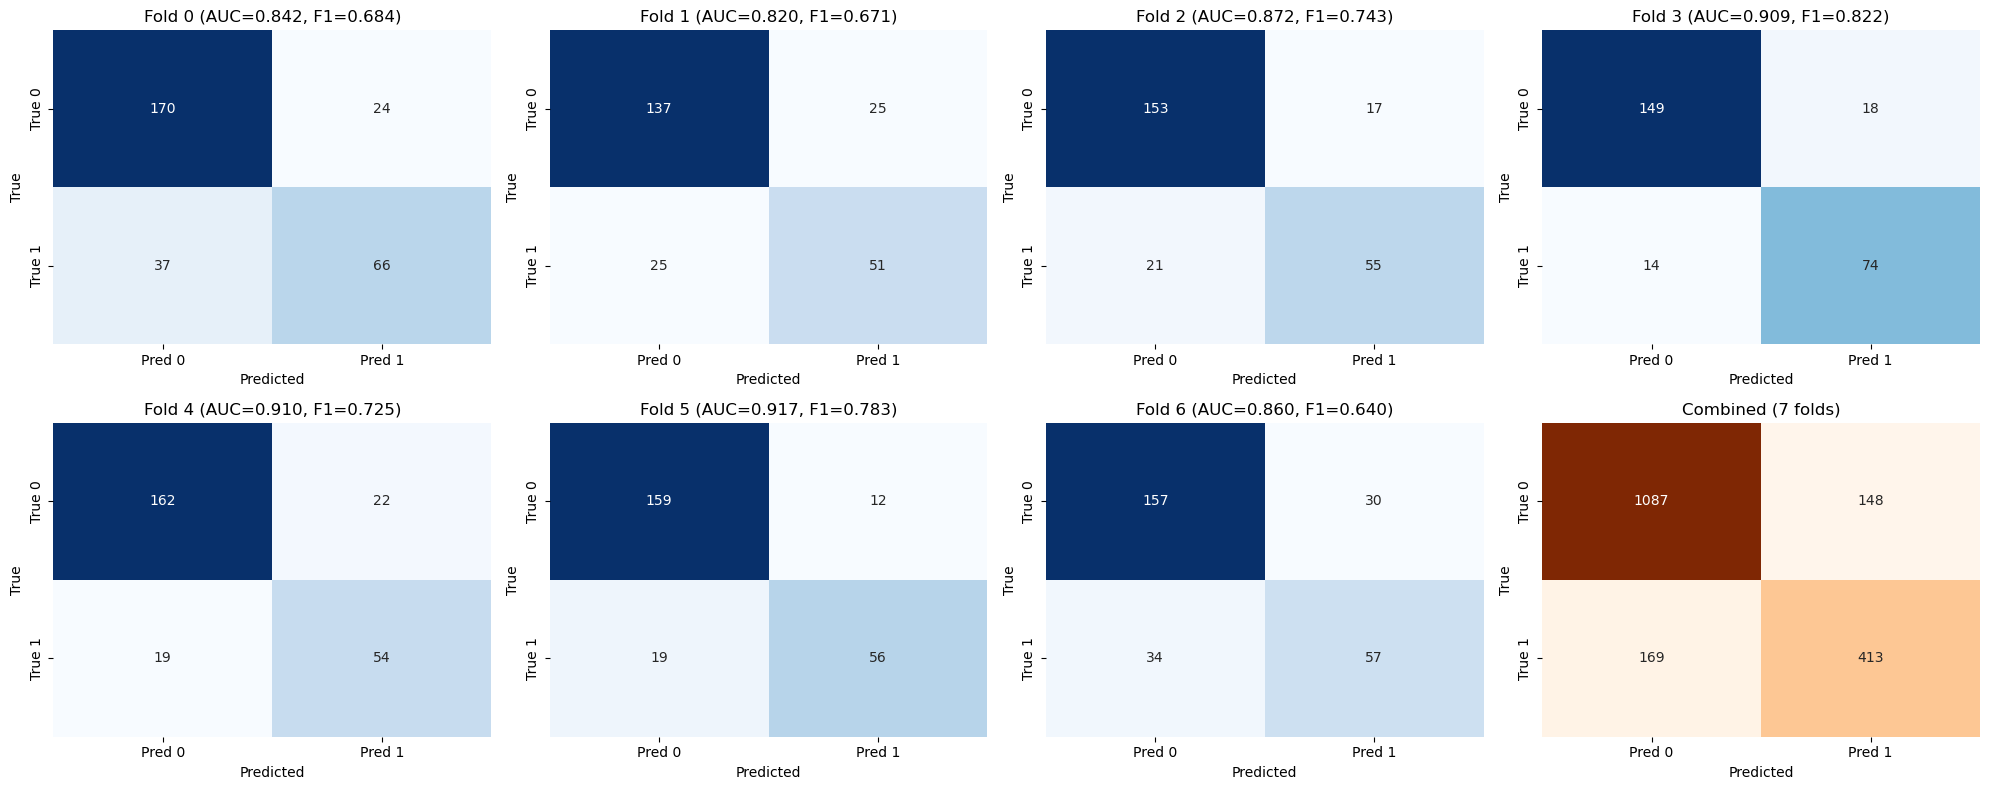

/tmp/ipykernel_8617/3365572909.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=metrics, showmeans=True, meanline=True,


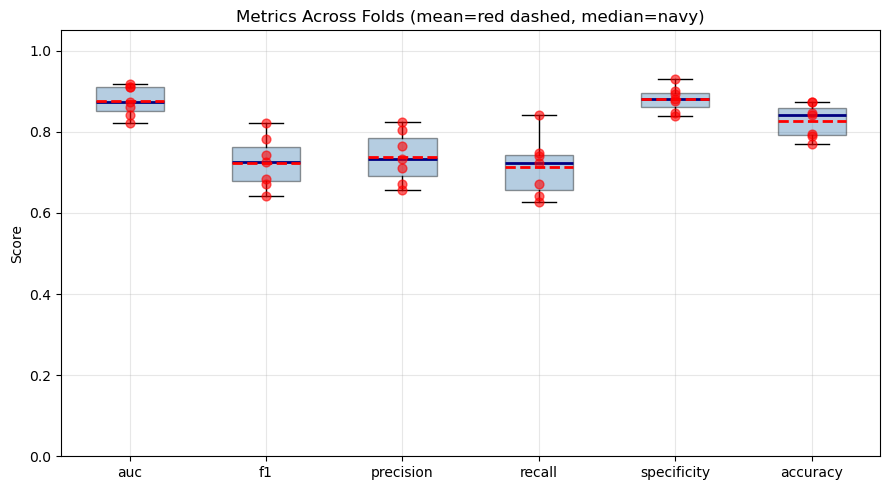


✓ All plots saved to: MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_demo_2stage


In [45]:
summary_mednet_demo = aggregate_results_binary(all_results_mednet_demo)
generate_experiment_report(
    all_results_mednet_demo, summary_mednet_demo,
    EXP_DIR_DEMO, EXPERIMENT_NAME_DEMO)

In [46]:
# =================================================================
#  Hold-out ensemble inference — shared helper for all MedNet strategies
# =================================================================
import json, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_fscore_support,
                             confusion_matrix, classification_report)

# Shared hold-out set (same patients used for the CNN — keeps model families comparable)
HOLDOUT_JSON = Path("MTA_atrophy_CNN/results_mta_atrophy/holdout_inference_set.json")


def full_metrics(preds, probs, labels, thr, label=""):
    try:    auc = roc_auc_score(labels, probs)
    except: auc = float('nan')
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    acc  = float((preds == labels).mean())
    print(f"\n{'─'*55}\n  {label}\n{'─'*55}")
    print(f"  AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  Thr={thr:.3f}")
    print(f"  Prec={prec:.3f}  Rec={rec:.3f}  Spec={spec:.3f}")
    print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
    print(classification_report(labels, preds,
          target_names=['Healthy (0)', 'Atrophic (1)'], digits=3))
    return dict(auc=auc, f1=f1, precision=prec, recall=rec,
                specificity=spec, accuracy=acc, threshold=thr,
                TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn))


class _DemoHoldoutDS(Dataset):
    """Holds preloaded images + a per-fold demographic array. Returns (x, demo, y, w)."""
    def __init__(self, cache, targets, demo_arr):
        self.cache   = cache
        self.targets = targets
        self.demo    = torch.from_numpy(demo_arr).float()
    def __len__(self):  return len(self.cache)
    def __getitem__(self, i):
        return (torch.from_numpy(self.cache[i][None]).float(),
                self.demo[i],
                torch.tensor(self.targets[i]),
                torch.tensor(1.0))


def run_holdout_ensemble(strategy_name, final_dir, build_model,
                         labels_df, n_folds=7, demo=False):
    final_dir = Path(final_dir)

    # ── 1. Hold-out set ──────────────────────────────────────
    with open(HOLDOUT_JSON) as f:
        holdout = json.load(f)
    holdout_df  = labels_df[labels_df['image_id'].isin(holdout['image_ids'])].reset_index(drop=True)
    true_labels = holdout_df['MTA_ATROPHY'].values.astype(int)   # aligned to loader order
    n_dropped   = holdout['n_total'] - len(holdout_df)
    print(f"Strategy: {strategy_name}")
    print(f"Holdout: {holdout_df['PTID'].nunique()} patients, {len(holdout_df)} images, "
          f"{100*true_labels.mean():.1f}% positive"
          + (f"  ({n_dropped} dropped — missing demographics)" if demo and n_dropped else ""))

    # ── 2. Fold results (.pkl → configs + thresholds) ────────
    all_results = []
    for k in range(n_folds):
        with open(final_dir / f"fold_{k}.pkl", 'rb') as f:
            all_results.append(pickle.load(f))
        print(f"  ✓ Fold {k} loaded  "
              f"(test AUC={all_results[-1]['test_results']['auc']:.3f}  "
              f"thr={all_results[-1]['test_results']['threshold']:.3f})")

    # ── 3. Inference per fold ────────────────────────────────
    fold_probs, fold_thresholds = [], []

    if not demo:
        print("\nBuilding holdout loader...")
        holdout_ds     = ADNIDataset(holdout_df, PREP_DIR, target_col='MTA_ATROPHY', preload=True)
        holdout_loader = DataLoader(holdout_ds, batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=NUM_WORKERS, pin_memory=True)
        for k, res in enumerate(all_results):
            model = build_model(res['config']).to(DEVICE)
            model.load_state_dict(torch.load(final_dir / f"fold_{k}_best_model.pt", map_location=DEVICE))
            probs, _ = evaluate(model, holdout_loader, DEVICE)
            fold_probs.append(probs)
            fold_thresholds.append(res['test_results']['threshold'])
            del model; torch.cuda.empty_cache()
            print(f"  ✓ Fold {k} inference done")
    else:
        print("\nPreloading holdout images once...")
        cache = [np.load(PREP_DIR / f"{i}.npy").astype(np.float32) for i in holdout_df['image_id']]
        print(f"  Preloaded {len(cache)} images")
        for k, res in enumerate(all_results):
            demo_arr = transform_demo(holdout_df, res['demo_scaler'])   # fold-specific scaler
            loader   = DataLoader(_DemoHoldoutDS(cache, true_labels.astype(np.float32), demo_arr),
                                  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
            model = build_model(res['config']).to(DEVICE)
            model.load_state_dict(torch.load(final_dir / f"fold_{k}_best_model.pt", map_location=DEVICE))
            probs, _ = evaluate_demo(model, loader, DEVICE)
            fold_probs.append(probs)
            fold_thresholds.append(res['test_results']['threshold'])
            del model; torch.cuda.empty_cache()
            print(f"  ✓ Fold {k} inference done")

    fold_probs      = np.stack(fold_probs, axis=0)
    fold_thresholds = np.array(fold_thresholds)

    # ── 4. Ensemble predictions ──────────────────────────────
    hard_votes    = (fold_probs >= fold_thresholds[:, None]).astype(int)
    majority_pred = (hard_votes.mean(axis=0) >= 0.5).astype(int)
    vote_count    = hard_votes.sum(axis=0)

    avg_probs        = fold_probs.mean(axis=0)
    mean_thr         = float(fold_thresholds.mean())
    soft_pred        = (avg_probs >= mean_thr).astype(int)
    best_thr_soft, _ = find_best_threshold(avg_probs, true_labels)
    soft_tuned_pred  = (avg_probs >= best_thr_soft).astype(int)

    # ── 5. Metrics ───────────────────────────────────────────
    print("\n" + "="*65)
    print(f"  ENSEMBLE — HOLDOUT SET  ({n_folds} models × {len(holdout_df)} samples)")
    print(f"  {strategy_name}")
    print("="*65)
    mv_metrics  = full_metrics(majority_pred,   avg_probs, true_labels, thr=0.5,
                               label="MAJORITY VOTE (hard, per-fold thresholds)")
    sv_metrics  = full_metrics(soft_pred,       avg_probs, true_labels, thr=mean_thr,
                               label="SOFT VOTE (mean prob, mean threshold)")
    svt_metrics = full_metrics(soft_tuned_pred, avg_probs, true_labels, thr=best_thr_soft,
                               label="SOFT VOTE (mean prob, tuned threshold)")

    # ── 6. Plots (identical layout to CNN) ───────────────────
    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(f"Ensemble on Held-Out Set — {strategy_name}", fontsize=15, fontweight='bold')
    gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

    for col, (preds, title) in enumerate([
        (majority_pred,   "Majority Vote\n(hard)"),
        (soft_pred,       "Soft Vote\n(mean thr)"),
        (soft_tuned_pred, "Soft Vote\n(tuned thr)"),
    ]):
        ax = fig.add_subplot(gs[0, col])
        cm = confusion_matrix(true_labels, preds, labels=[0, 1])
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        for i in range(2):
            for j in range(2):
                ax.text(j+0.5, i+0.75, f"({100*cm_pct[i,j]:.1f}%)",
                        ha='center', va='center', fontsize=8, color='dimgray')
        ax.set_title(title, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

    ax_roc = fig.add_subplot(gs[1, 0:2])
    fpr, tpr, _ = roc_curve(true_labels, avg_probs)
    auc_ens = roc_auc_score(true_labels, avg_probs)
    for i, res in enumerate(all_results):
        f, t, _ = roc_curve(np.array(res['test_labels']), np.array(res['test_probs']))
        ax_roc.plot(f, t, alpha=0.2, color='gray',
                    label='Individual fold test' if i == 0 else '_nolegend_')
    ax_roc.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Ensemble — holdout (AUC={auc_ens:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax_roc.axvline(0.1, color='coral', ls=':', alpha=0.5, label='FPR=0.10')
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title('ROC — Ensemble (holdout) vs Individual Fold Test Sets')
    ax_roc.legend(loc='lower right', fontsize=8); ax_roc.grid(alpha=0.3)

    ax_bar = fig.add_subplot(gs[1, 2])
    keys  = ['auc', 'f1', 'precision', 'recall', 'specificity', 'accuracy']
    names = ['AUC', 'F1', 'Prec', 'Rec', 'Spec', 'Acc']
    x = np.arange(len(keys)); w = 0.25
    ax_bar.bar(x-w, [mv_metrics[k]  for k in keys], w, label='Majority',    color='steelblue',      alpha=0.85)
    ax_bar.bar(x,   [sv_metrics[k]  for k in keys], w, label='Soft(mean)',  color='mediumseagreen', alpha=0.85)
    ax_bar.bar(x+w, [svt_metrics[k] for k in keys], w, label='Soft(tuned)', color='coral',          alpha=0.85)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(names, fontsize=8)
    ax_bar.set_ylim(0, 1.12); ax_bar.set_ylabel('Score')
    ax_bar.set_title('Ensemble Metrics Comparison'); ax_bar.legend(fontsize=7); ax_bar.grid(axis='y', alpha=0.3)
    for bars in ax_bar.containers:
        ax_bar.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)

    ax_v = fig.add_subplot(gs[2, 0])
    ax_v.hist([vote_count[true_labels == 1], vote_count[true_labels == 0]],
              bins=np.arange(-0.5, n_folds+1.5), label=['Atrophic (1)', 'Healthy (0)'],
              color=['#d9534f', '#5bc0de'], alpha=0.7, edgecolor='white')
    ax_v.axvline(n_folds/2, color='black', ls='--', lw=1.5, label='Majority thr')
    ax_v.set_xlabel('# Folds Voting Positive'); ax_v.set_ylabel('# Samples')
    ax_v.set_title('Vote Count Distribution by True Class')
    ax_v.legend(fontsize=8); ax_v.grid(alpha=0.3); ax_v.set_xticks(range(n_folds+1))

    ax_p = fig.add_subplot(gs[2, 1])
    ax_p.hist(avg_probs[true_labels == 0], bins=40, alpha=0.6, color='#5bc0de', label='Healthy (0)', density=True)
    ax_p.hist(avg_probs[true_labels == 1], bins=40, alpha=0.6, color='#d9534f', label='Atrophic (1)', density=True)
    ax_p.axvline(mean_thr,      color='navy',       ls='--', lw=1.5, label=f'Mean thr ({mean_thr:.2f})')
    ax_p.axvline(best_thr_soft, color='darkorange', ls=':',  lw=1.5, label=f'Tuned thr ({best_thr_soft:.2f})')
    ax_p.set_xlabel('Ensemble Average Probability'); ax_p.set_ylabel('Density')
    ax_p.set_title('Ensemble Probability Distribution by Class')
    ax_p.legend(fontsize=8); ax_p.grid(alpha=0.3)

    ax_h = fig.add_subplot(gs[2, 2])
    sort_idx  = np.lexsort((avg_probs, true_labels))
    sample100 = sort_idx[np.linspace(0, len(sort_idx)-1, min(100, len(sort_idx)), dtype=int)]
    sns.heatmap(hard_votes[:, sample100], cmap='Blues', cbar=False, ax=ax_h,
                xticklabels=False, yticklabels=[f"F{i}" for i in range(n_folds)])
    ax_h.axvline((true_labels[sample100] == 0).sum(), color='red', lw=1.5, ls='--')
    ax_h.set_xlabel('Samples (sorted: Healthy | Atrophic)')
    ax_h.set_title('Model Agreement Map\n(samples sorted, red = class boundary)')

    plt.savefig(final_dir / "ensemble_holdout_voting.png", dpi=130, bbox_inches='tight')
    plt.show()
    print(f"\n✓ Plot saved → {final_dir / 'ensemble_holdout_voting.png'}")

    # ── 7. Save results ──────────────────────────────────────
    ensemble_out = {
        'strategy':            strategy_name,
        'n_folds':             n_folds,
        'n_patients':          int(holdout_df['PTID'].nunique()),
        'n_samples':           int(len(holdout_df)),
        'n_positive':          int(true_labels.sum()),
        'positive_rate':       float(true_labels.mean()),
        'fold_thresholds':     fold_thresholds.tolist(),
        'majority_vote':       mv_metrics,
        'soft_vote_mean_thr':  sv_metrics,
        'soft_vote_tuned_thr': svt_metrics,
        'avg_probs':           avg_probs.tolist(),
        'vote_counts':         vote_count.tolist(),
        'true_labels':         true_labels.tolist(),
        'image_ids':           holdout_df['image_id'].tolist(),
    }
    out_json = final_dir / "ensemble_holdout_results.json"
    with open(out_json, 'w') as f:
        json.dump(ensemble_out, f, indent=2)
    print(f"✓ Results saved → {out_json}")
    return ensemble_out

Strategy: MedicalNet ResNet-10 — single-stage
Holdout: 98 patients, 203 images, 32.5% positive
  ✓ Fold 0 loaded  (test AUC=0.854  thr=0.685)
  ✓ Fold 1 loaded  (test AUC=0.869  thr=0.765)
  ✓ Fold 2 loaded  (test AUC=0.866  thr=0.575)
  ✓ Fold 3 loaded  (test AUC=0.890  thr=0.590)
  ✓ Fold 4 loaded  (test AUC=0.881  thr=0.690)
  ✓ Fold 5 loaded  (test AUC=0.858  thr=0.555)
  ✓ Fold 6 loaded  (test AUC=0.820  thr=0.645)

Building holdout loader...
  Preloaded 203 images (0.7 GB)


/tmp/ipykernel_8617/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 0 inference done
  ✓ Fold 1 inference done
  ✓ Fold 2 inference done
  ✓ Fold 3 inference done
  ✓ Fold 4 inference done
  ✓ Fold 5 inference done
  ✓ Fold 6 inference done

  ENSEMBLE — HOLDOUT SET  (7 models × 203 samples)
  MedicalNet ResNet-10 — single-stage

───────────────────────────────────────────────────────
  MAJORITY VOTE (hard, per-fold thresholds)
───────────────────────────────────────────────────────
  AUC=0.906  F1=0.688  Acc=0.808  Thr=0.500
  Prec=0.729  Rec=0.652  Spec=0.883
  TP=43  FP=16  TN=121  FN=23
              precision    recall  f1-score   support

 Healthy (0)      0.840     0.883     0.861       137
Atrophic (1)      0.729     0.652     0.688        66

    accuracy                          0.808       203
   macro avg      0.785     0.767     0.775       203
weighted avg      0.804     0.808     0.805       203


───────────────────────────────────────────────────────
  SOFT VOTE (mean prob, mean threshold)
─────────────────────────────────────

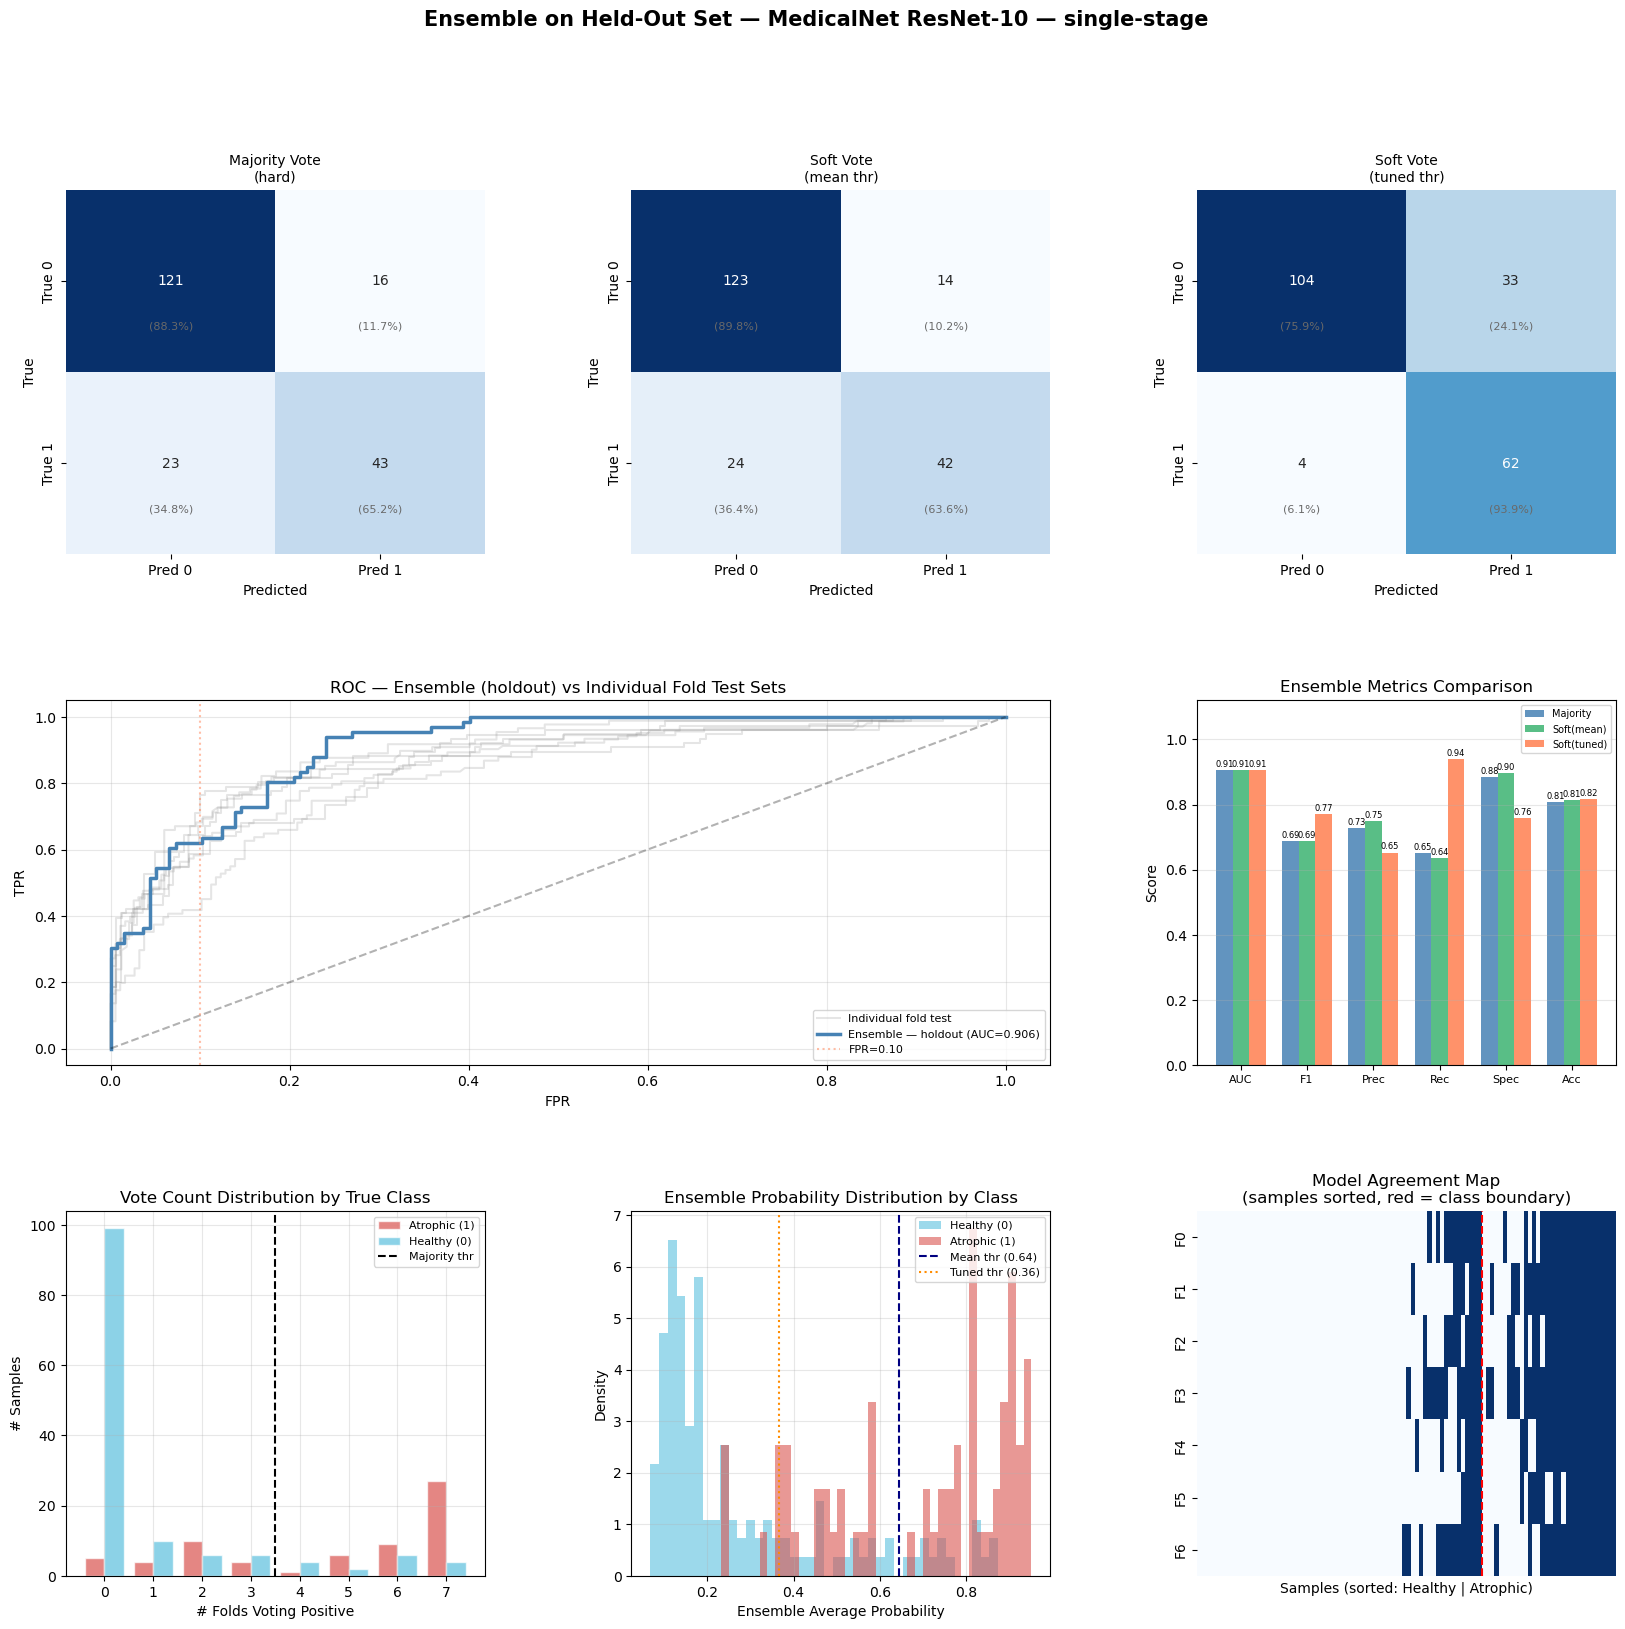


✓ Plot saved → MTA_atrophy_MedicalNet/results_mta_atrophy/final_mednet_macroF1/ensemble_holdout_voting.png
✓ Results saved → MTA_atrophy_MedicalNet/results_mta_atrophy/final_mednet_macroF1/ensemble_holdout_results.json


In [47]:
ens_mednet_single = run_holdout_ensemble(
    strategy_name = "MedicalNet ResNet-10 — single-stage",
    final_dir     = RESULTS_DIR_MedNet / "final_mednet_macroF1",
    build_model   = lambda cfg: MedicalNetResNet10(n_classes=1, dropout=cfg['dropout']),
    labels_df     = labels,
)

Strategy: MedicalNet ResNet-10 — 2-stage
Holdout: 98 patients, 203 images, 32.5% positive
  ✓ Fold 0 loaded  (test AUC=0.863  thr=0.485)
  ✓ Fold 1 loaded  (test AUC=0.884  thr=0.790)
  ✓ Fold 2 loaded  (test AUC=0.839  thr=0.600)
  ✓ Fold 3 loaded  (test AUC=0.886  thr=0.580)
  ✓ Fold 4 loaded  (test AUC=0.940  thr=0.765)
  ✓ Fold 5 loaded  (test AUC=0.893  thr=0.300)
  ✓ Fold 6 loaded  (test AUC=0.836  thr=0.305)

Building holdout loader...
  Preloaded 203 images (0.7 GB)


/tmp/ipykernel_8617/819640280.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 0 inference done
  ✓ Fold 1 inference done
  ✓ Fold 2 inference done
  ✓ Fold 3 inference done
  ✓ Fold 4 inference done
  ✓ Fold 5 inference done
  ✓ Fold 6 inference done

  ENSEMBLE — HOLDOUT SET  (7 models × 203 samples)
  MedicalNet ResNet-10 — 2-stage

───────────────────────────────────────────────────────
  MAJORITY VOTE (hard, per-fold thresholds)
───────────────────────────────────────────────────────
  AUC=0.911  F1=0.720  Acc=0.828  Thr=0.500
  Prec=0.763  Rec=0.682  Spec=0.898
  TP=45  FP=14  TN=123  FN=21
              precision    recall  f1-score   support

 Healthy (0)      0.854     0.898     0.875       137
Atrophic (1)      0.763     0.682     0.720        66

    accuracy                          0.828       203
   macro avg      0.808     0.790     0.798       203
weighted avg      0.824     0.828     0.825       203


───────────────────────────────────────────────────────
  SOFT VOTE (mean prob, mean threshold)
──────────────────────────────────────────

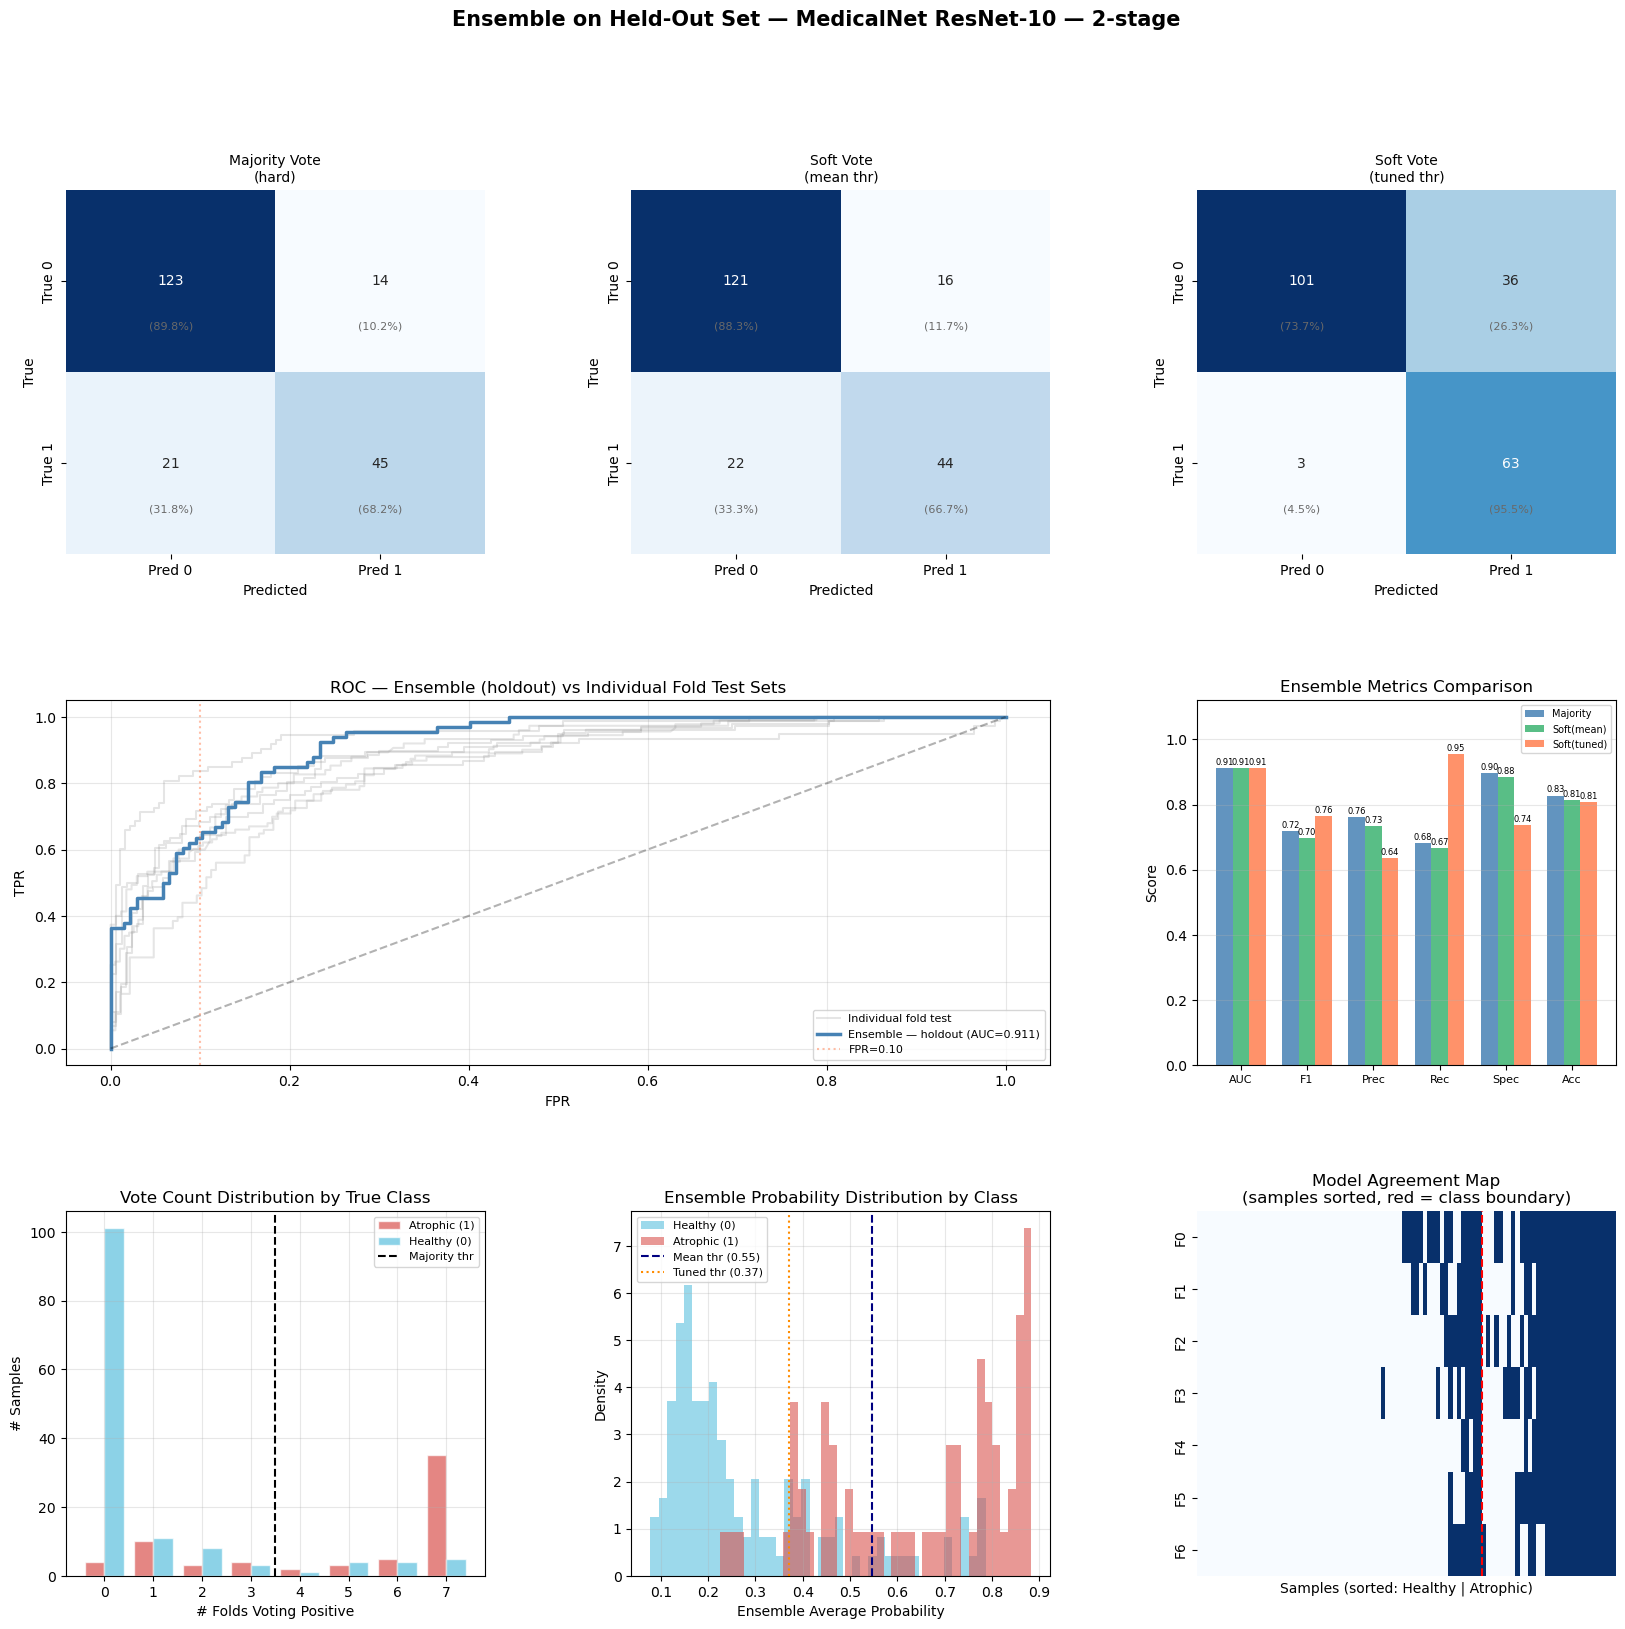


✓ Plot saved → MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_2stage/ensemble_holdout_voting.png
✓ Results saved → MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_2stage/ensemble_holdout_results.json


In [48]:
ens_mednet_2stage = run_holdout_ensemble(
    strategy_name = "MedicalNet ResNet-10 — 2-stage",
    final_dir     = RESULTS_DIR_MedNet / "medicalnet_resnet10_2stage",
    build_model   = lambda cfg: MedicalNetResNet10(n_classes=1, dropout=cfg['dropout']),
    labels_df     = labels,
)

Strategy: MedicalNet ResNet-10 + Demographics
Holdout: 98 patients, 203 images, 32.5% positive
  ✓ Fold 0 loaded  (test AUC=0.842  thr=0.635)
  ✓ Fold 1 loaded  (test AUC=0.820  thr=0.320)
  ✓ Fold 2 loaded  (test AUC=0.872  thr=0.300)
  ✓ Fold 3 loaded  (test AUC=0.909  thr=0.315)
  ✓ Fold 4 loaded  (test AUC=0.910  thr=0.515)
  ✓ Fold 5 loaded  (test AUC=0.917  thr=0.415)
  ✓ Fold 6 loaded  (test AUC=0.860  thr=0.410)

Preloading holdout images once...
  Preloaded 203 images


/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 0 inference done


/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 1 inference done


...

  ✓ Fold 4 inference done


/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 5 inference done


/tmp/ipykernel_8617/1353601961.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ✓ Fold 6 inference done

  ENSEMBLE — HOLDOUT SET  (7 models × 203 samples)
  MedicalNet ResNet-10 + Demographics

───────────────────────────────────────────────────────
  MAJORITY VOTE (hard, per-fold thresholds)
───────────────────────────────────────────────────────
  AUC=0.917  F1=0.740  Acc=0.837  Thr=0.500
  Prec=0.770  Rec=0.712  Spec=0.898
  TP=47  FP=14  TN=123  FN=19
              precision    recall  f1-score   support

 Healthy (0)      0.866     0.898     0.882       137
Atrophic (1)      0.770     0.712     0.740        66

    accuracy                          0.837       203
   macro avg      0.818     0.805     0.811       203
weighted avg      0.835     0.837     0.836       203


───────────────────────────────────────────────────────
  SOFT VOTE (mean prob, mean threshold)
───────────────────────────────────────────────────────
  AUC=0.917  F1=0.727  Acc=0.823  Thr=0.416
  Prec=0.727  Rec=0.727  Spec=0.869
  TP=48  FP=18  TN=119  FN=18
              precision    

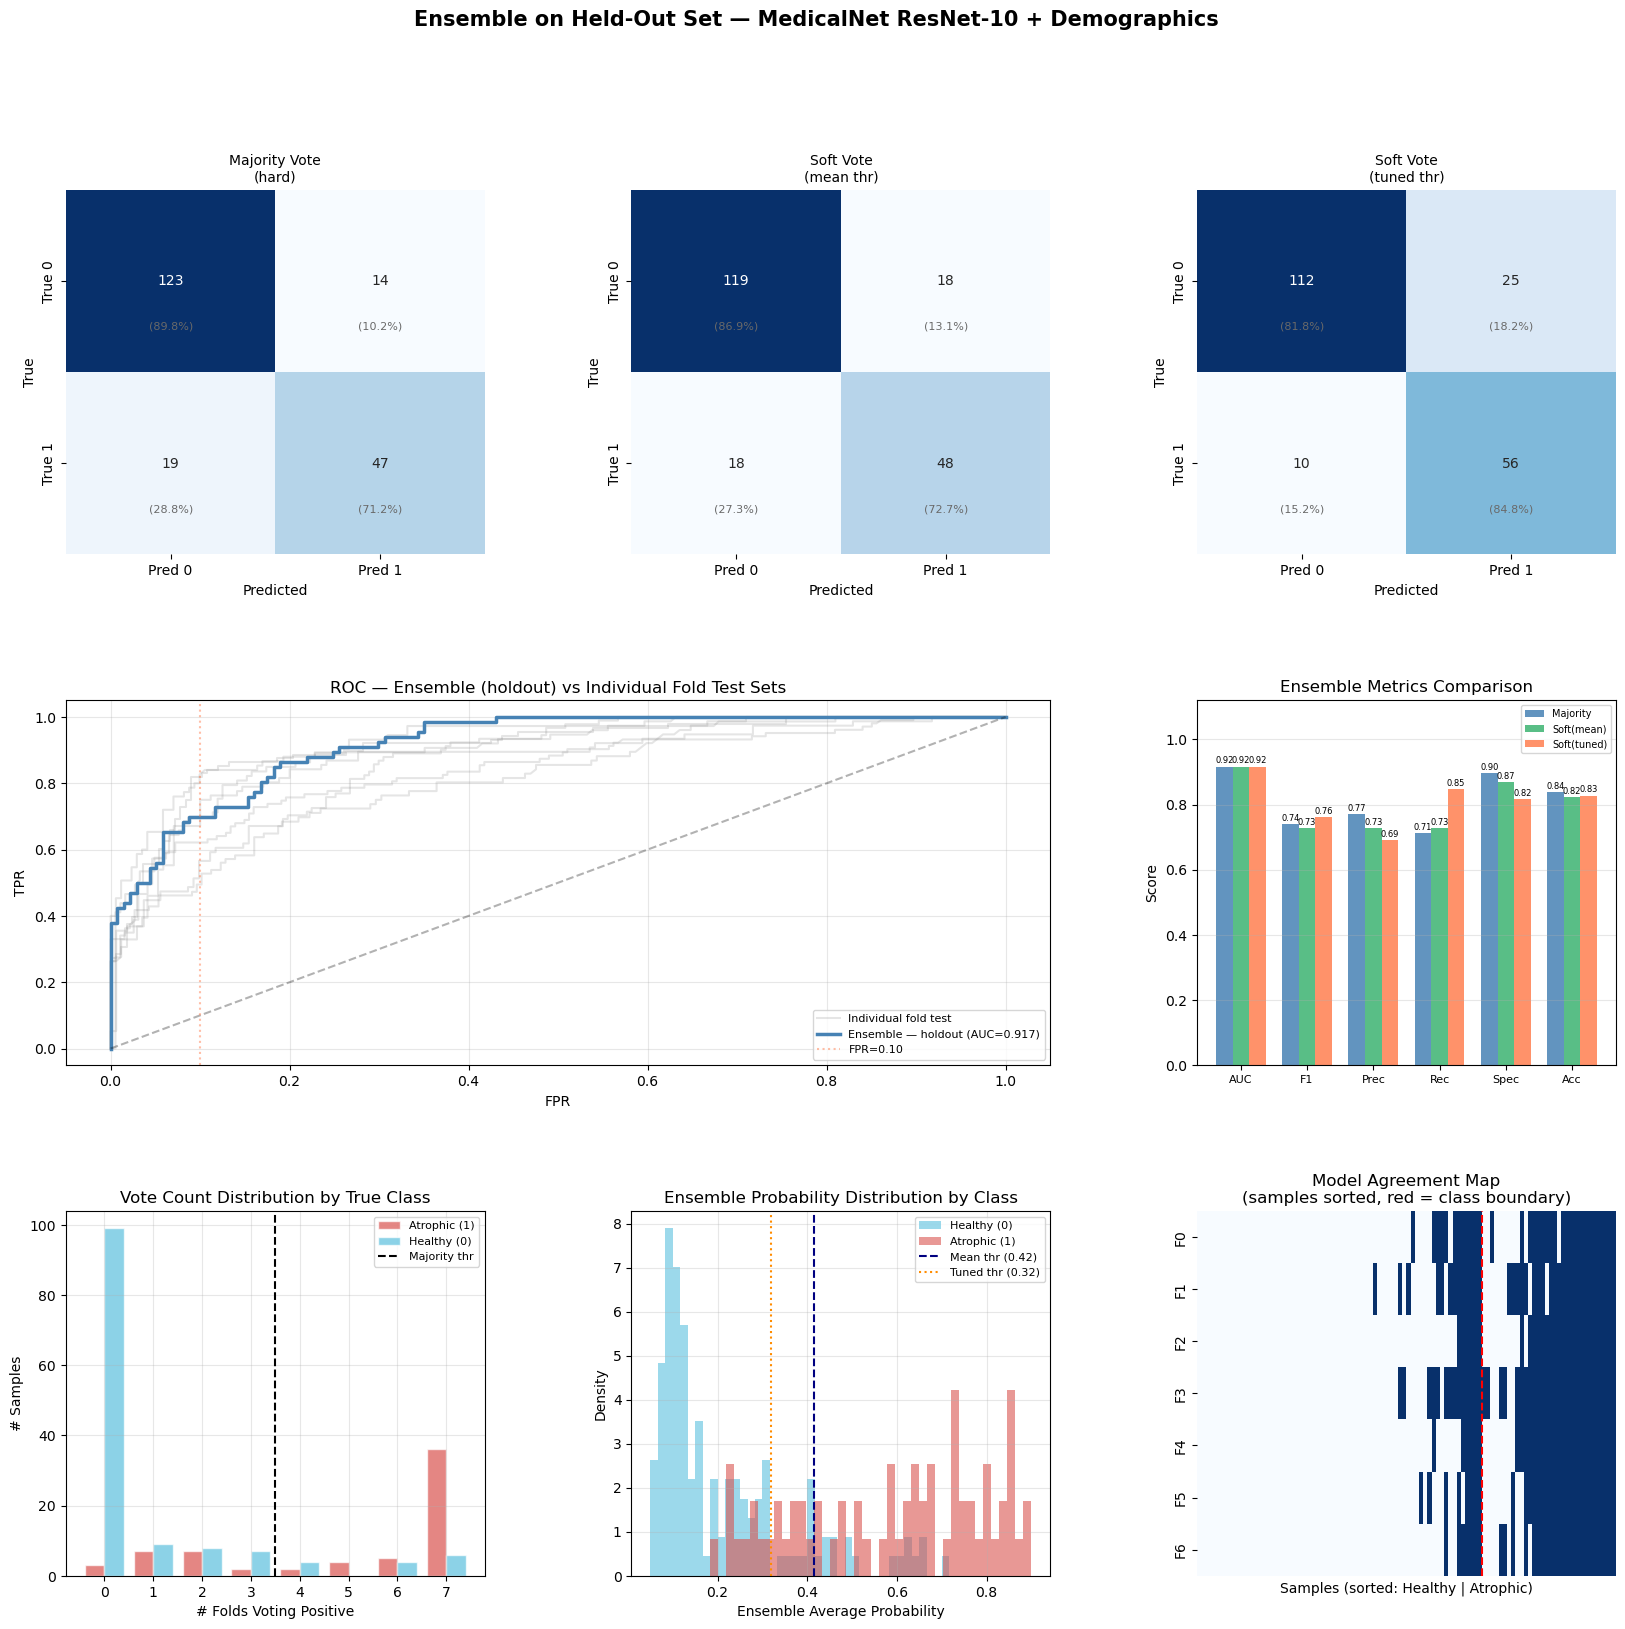


✓ Plot saved → MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_demo_2stage/ensemble_holdout_voting.png
✓ Results saved → MTA_atrophy_MedicalNet/results_mta_atrophy/medicalnet_resnet10_demo_2stage/ensemble_holdout_results.json


In [49]:
ens_mednet_demo = run_holdout_ensemble(
    strategy_name = "MedicalNet ResNet-10 + Demographics",
    final_dir     = RESULTS_DIR_MedNet / "medicalnet_resnet10_demo_2stage",
    build_model   = lambda cfg: MedicalNetResNet10Demo(
                        n_demo_features=3, demo_hidden=cfg['demo_hidden'],
                        n_classes=1, dropout=cfg['dropout']),
    labels_df     = labels_demo,   # demographics-filtered df
    demo          = True,          # uses each fold's saved demo_scaler
)